# Trajectory and velocity analysis of scRNAseq COLON data 

This is one in the series of notebooks presenting the data analysis done in the study "Widespread epithelial dedifferentiation in patients with ulcerative colitis". It is also intended as a tutorial in scRNAseq analysis. Please refer to the REAMDE file for the description of different parts of the tutorial and how to follow it.  

## Part 1. Data load and quality control

### Ulcerated dataset

This notebook shows the results and parameter choices for the "Ulcerated dataset" (see study for details regarding samples constituting the dataset). I am not providing detailed descriptions of each step here. Those can be found in the notebook for the Healthy dataset. Please refer to the file `Healthy_qc.ipynb`

#### 0. Imports and settings

In [1]:
import scanpy as sc
import scvelo as scv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
import scrublet as scr
import doubletdetection

#### 1. Load data

In [2]:
sample_name = "ulcerated1"
file = "data/{}.loom".format(sample_name)
adata1 = scv.read_loom(file, sparse=True, cleanup=True)
adata1.var_names_make_unique()
# Delete obsolite data created by velocyto
del adata1.obs['Clusters']
del adata1.obs['_X']
del adata1.obs['_Y']
del adata1.var['Accession']
del adata1.var['Chromosome']
del adata1.var['End']
del adata1.var['Start']
del adata1.var['Strand']
del adata1.layers['ambiguous']

sample_name = "ulcerated2"
file = "data/{}.loom".format(sample_name)
adata2 = scv.read_loom(file, sparse=True, cleanup=True)
adata2.var_names_make_unique()
del adata2.obs['Clusters']
del adata2.obs['_X']
del adata2.obs['_Y']
del adata2.var['Accession']
del adata2.var['Chromosome']
del adata2.var['End']
del adata2.var['Start']
del adata2.var['Strand']
del adata2.layers['ambiguous']

sample_name = "ulcerated3"
file = "data/{}.loom".format(sample_name)
adata3 = scv.read_loom(file, sparse=True, cleanup=True)
adata3.var_names_make_unique()
del adata3.obs['Clusters']
del adata3.obs['_X']
del adata3.obs['_Y']
del adata3.var['Accession']
del adata3.var['Chromosome']
del adata3.var['End']
del adata3.var['Start']
del adata3.var['Strand']
del adata3.layers['ambiguous']

sample_name = "ulcerated4"
file = "data/{}.loom".format(sample_name)
adata4 = scv.read_loom(file, sparse=True, cleanup=True)
adata4.var_names_make_unique()
del adata4.obs['Clusters']
del adata4.obs['_X']
del adata4.obs['_Y']
del adata4.var['Accession']
del adata4.var['Chromosome']
del adata4.var['End']
del adata4.var['Start']
del adata4.var['Strand']
del adata4.layers['ambiguous']

Variable names are not unique. To make them unique, call `.var_names_make_unique`.
Variable names are not unique. To make them unique, call `.var_names_make_unique`.
Variable names are not unique. To make them unique, call `.var_names_make_unique`.
Variable names are not unique. To make them unique, call `.var_names_make_unique`.


#### 2. Quality control

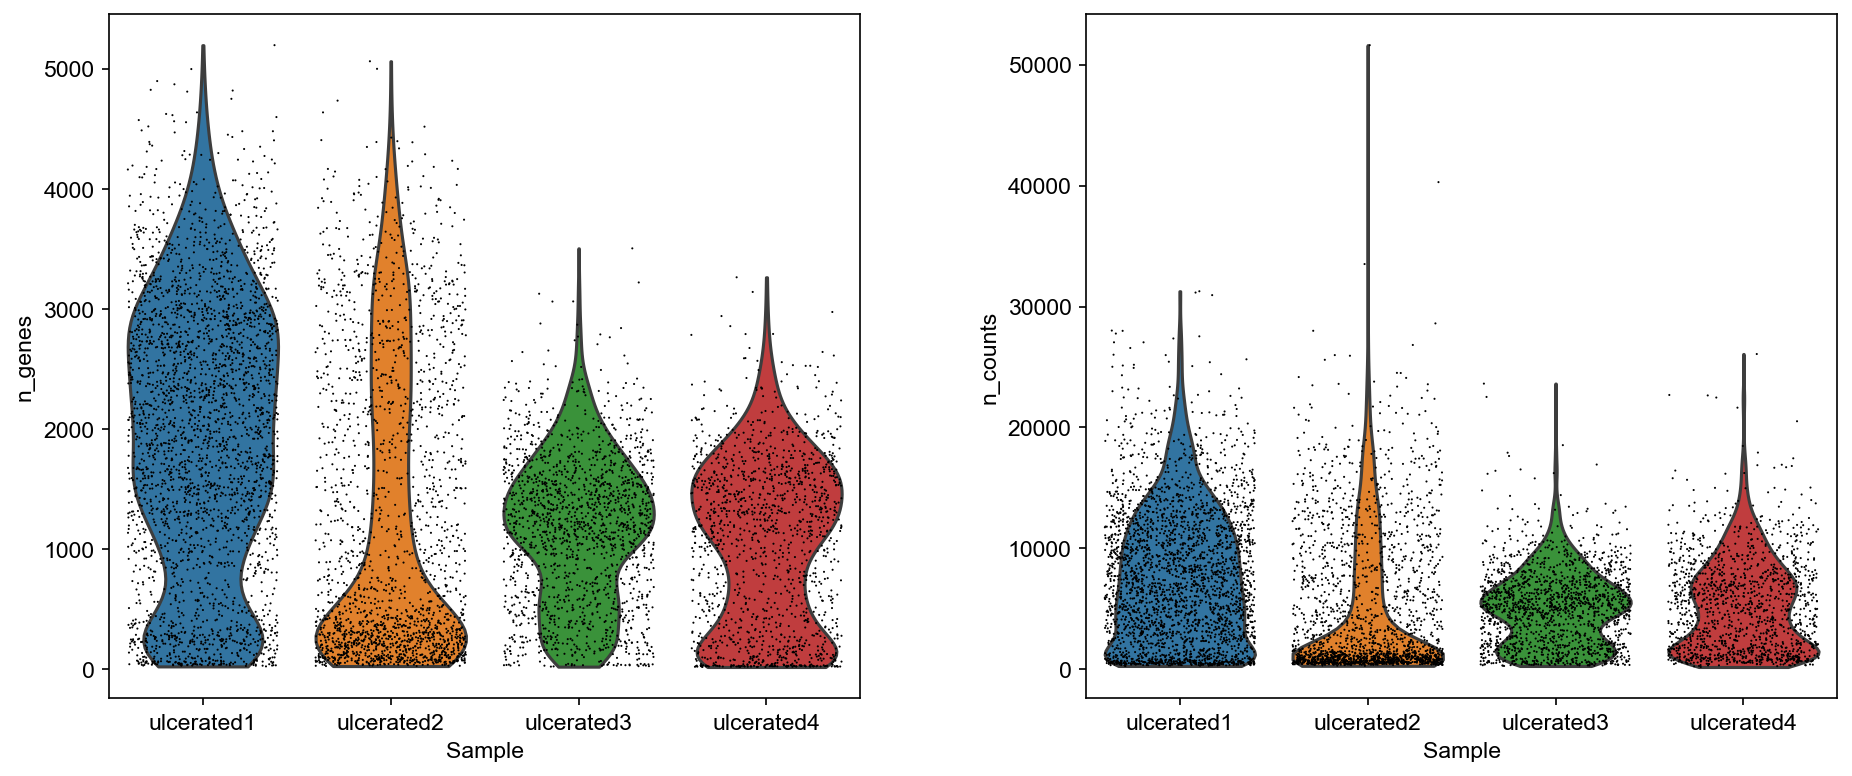

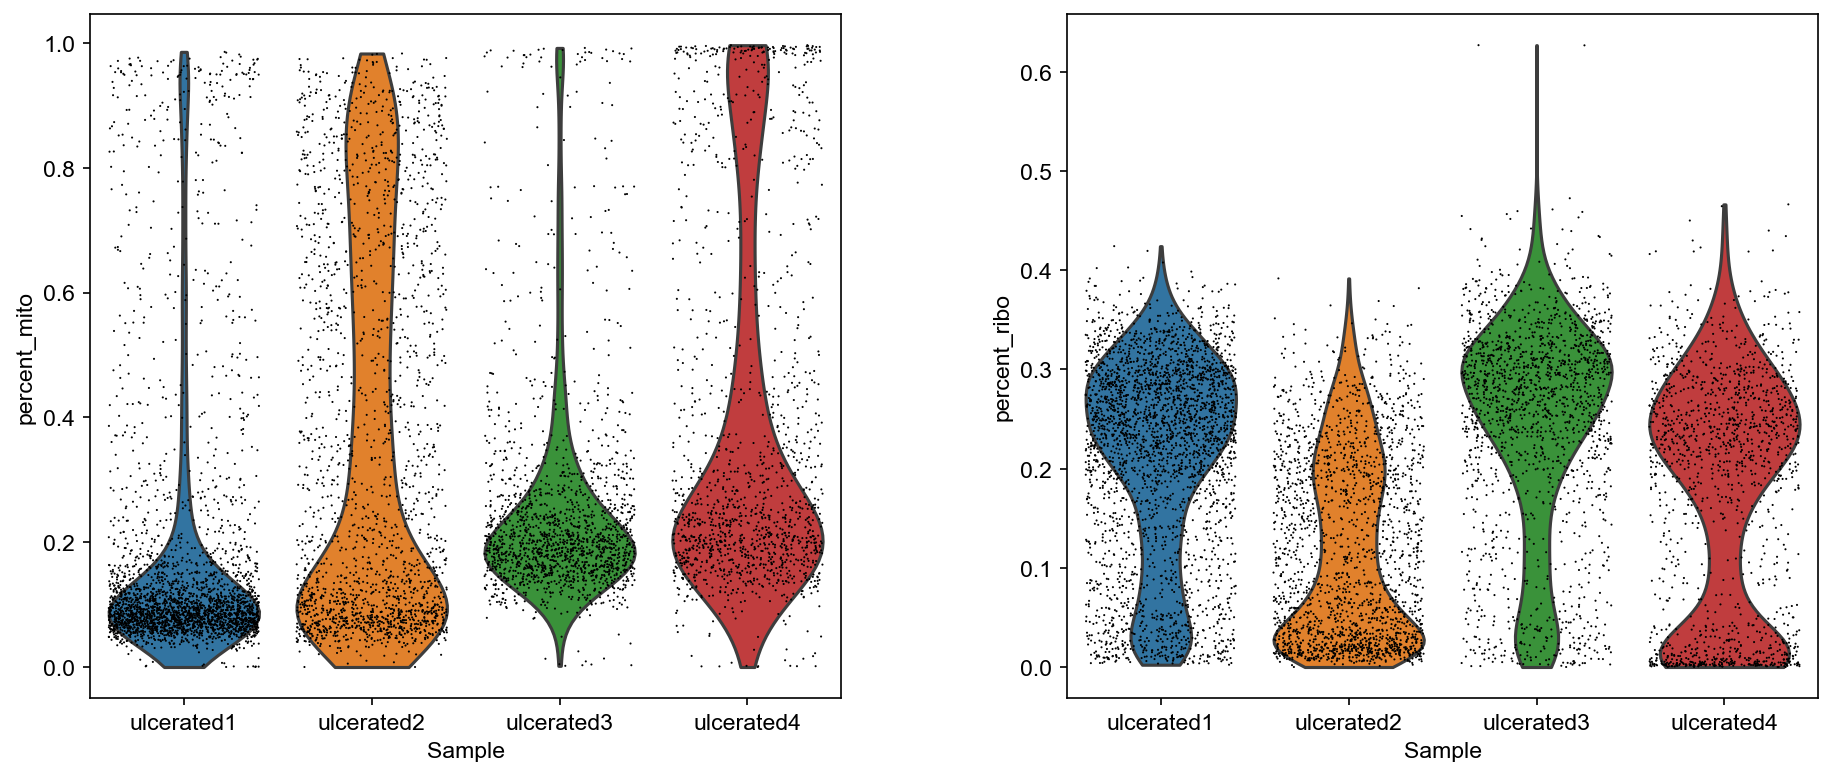

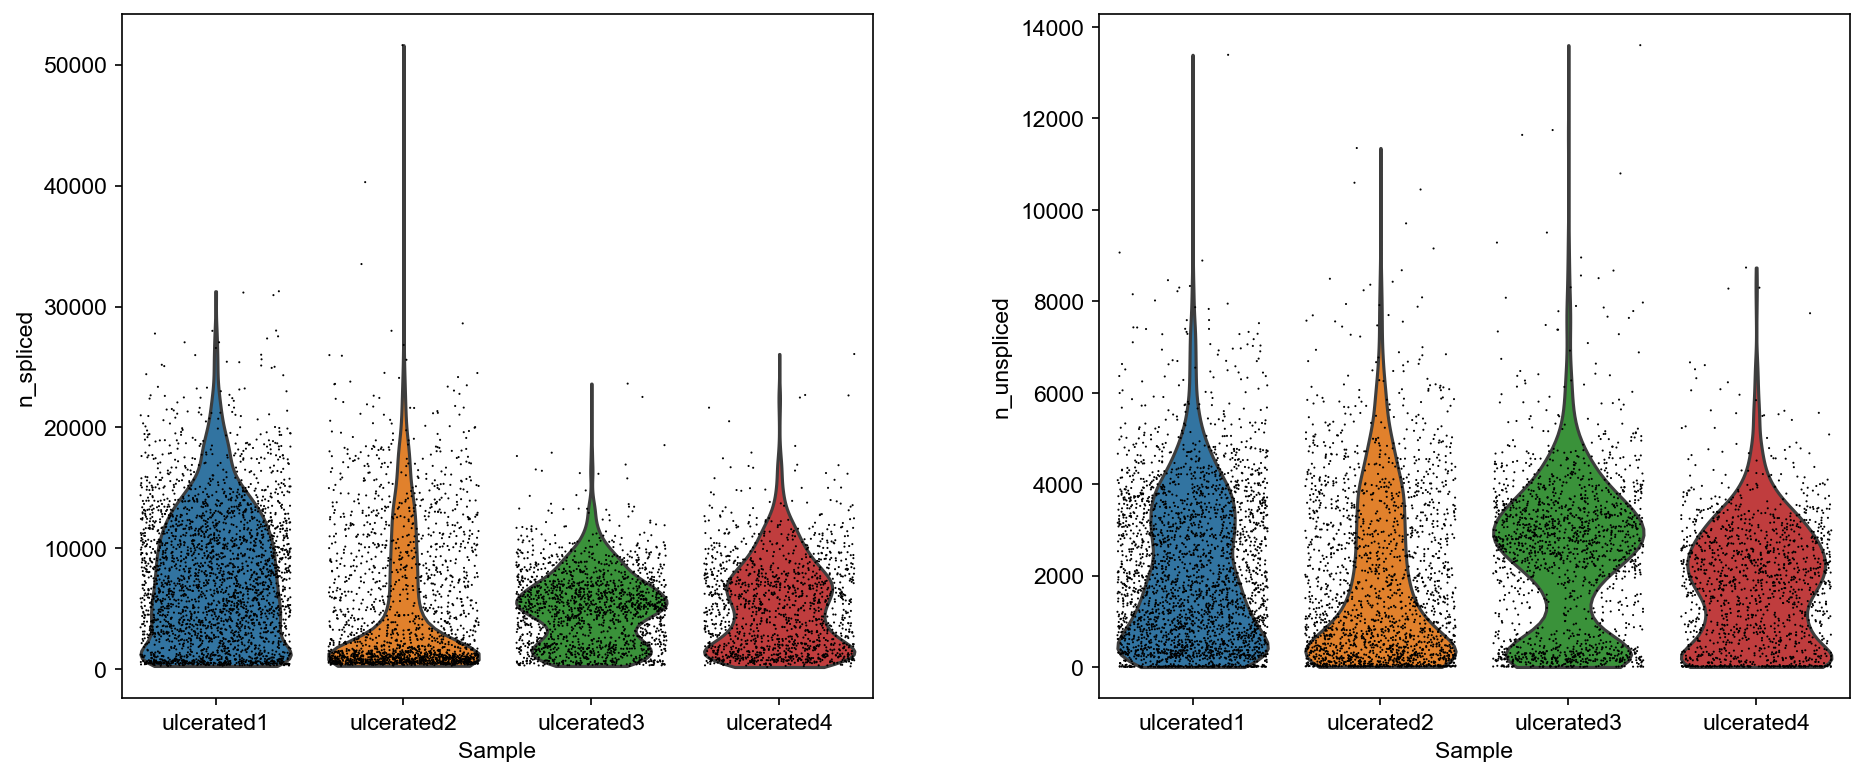

In [3]:
# Concatenate the files to calculate joint QC metrics
adata_qc = adata1.concatenate(adata2, adata3, adata4, 
                              batch_key='Sample', batch_categories=['ulcerated1', 'ulcerated2', 'ulcerated3', 'ulcerated4'])

# Calculate QC covariates
adata_qc.obs['n_counts'] = adata_qc.X.sum(1)
adata_qc.obs['n_spliced'] = adata_qc.layers['spliced'].sum(1)
adata_qc.obs['n_unspliced'] = adata_qc.layers['unspliced'].sum(1)
adata_qc.obs['n_genes'] = (adata_qc.X > 0).sum(1)
# Compute for each cell the fraction of counts in mitochondrial genes vs. all genes
mito_genes = adata_qc.var_names.str.startswith('MT-')
adata_qc.obs['percent_mito'] = np.sum(
    adata_qc[:, mito_genes].X, axis=1) / np.sum(adata_qc.X, axis=1)
# Compute for each cell the fraction of counts in ribosomal genes vs. all genes
ribo_genes = adata_qc.var_names.str.startswith('RP')
adata_qc.obs['percent_ribo'] = np.sum(
    adata_qc[:, ribo_genes].X, axis=1) / np.sum(adata_qc.X, axis=1)

# Initial plotting settings for more detailed scatter and dist plots.
scv.settings.set_figure_params('scvelo', dpi=75, vector_friendly=True, figsize=[6,6])

# Plot the statistics on a violin plot split by sample.
sc.pl.violin(adata_qc, ['n_genes', 'n_counts'], jitter=0.4, groupby='Sample')
sc.pl.violin(adata_qc, ['percent_mito', 'percent_ribo'], jitter=0.4, groupby='Sample')
sc.pl.violin(adata_qc, ['n_spliced', 'n_unspliced'], jitter=0.4, groupby='Sample')

##### 2.1 ulcerated1 QC 

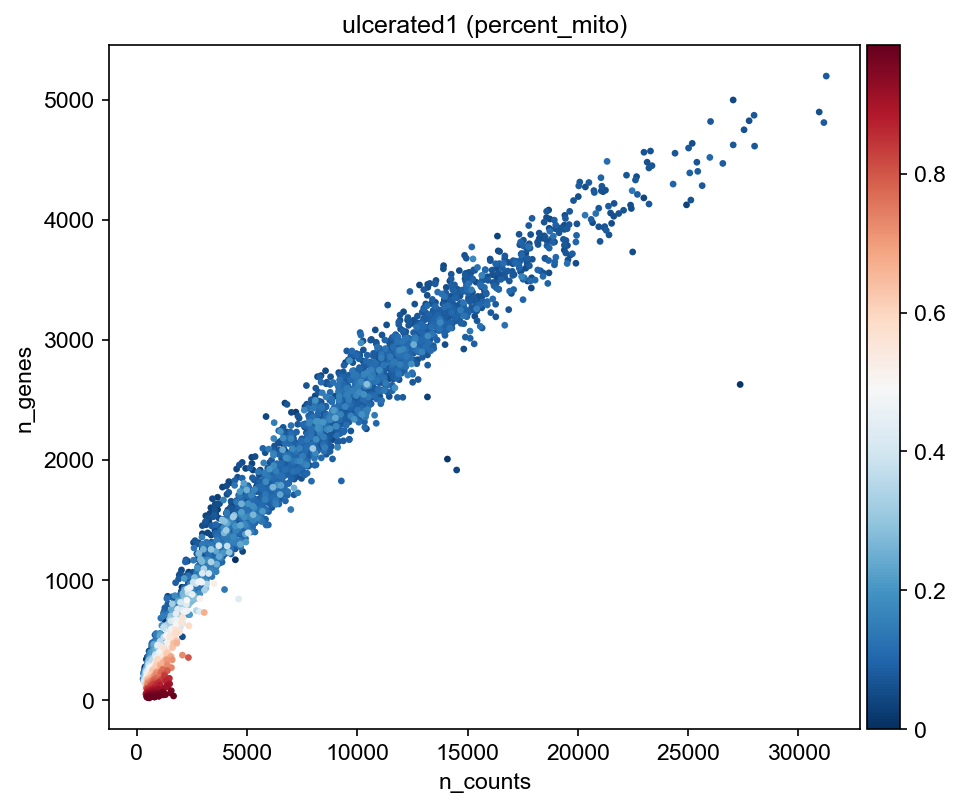

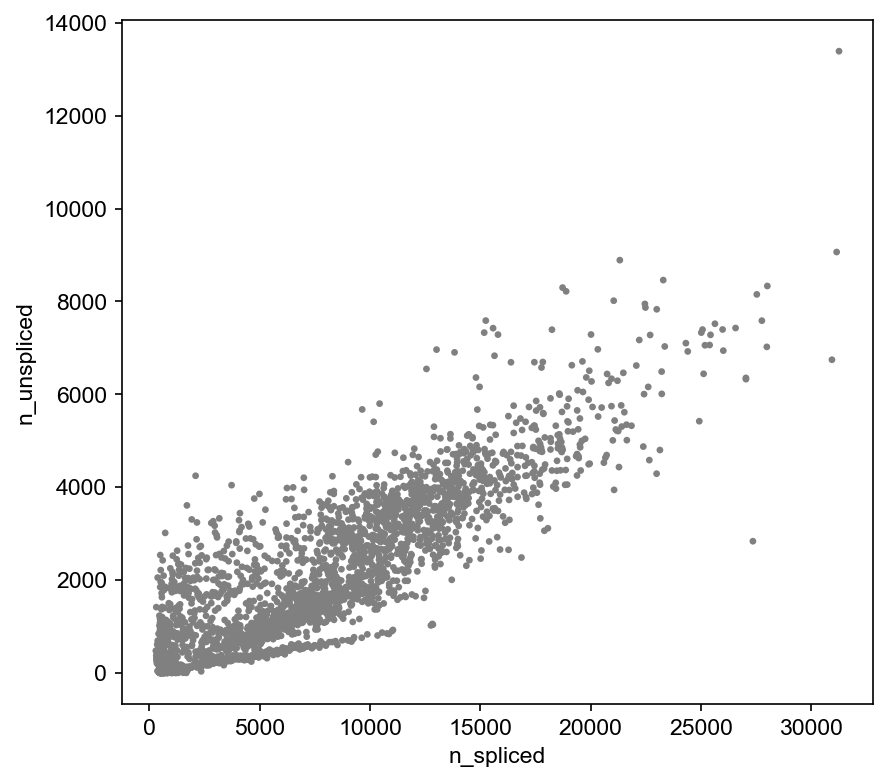

In [4]:
# Calculate QC covariates
adata1.obs['n_counts'] = adata1.X.sum(1)
adata1.obs['log_counts'] = np.log(adata1.obs['n_counts'])
adata1.obs['n_spliced'] = adata1.layers['spliced'].sum(1)
adata1.obs['n_unspliced'] = adata1.layers['unspliced'].sum(1)
adata1.obs['n_genes'] = (adata1.X > 0).sum(1)
# Compute for each cell the fraction of counts in mito genes vs. all genes
mito_genes = adata1.var_names.str.startswith('MT-')
adata1.obs['percent_mito'] = np.sum(
    adata1[:, mito_genes].X, axis=1) / np.sum(adata1.X, axis=1)
# Compute for each cell the fraction of counts in ribosomal genes vs. all genes
ribo_genes = adata1.var_names.str.startswith('RP')
adata1.obs['percent_ribo'] = np.sum(
    adata1[:, ribo_genes].X, axis=1) / np.sum(adata1.X, axis=1)

sc.pl.scatter(adata1, 'n_counts', 'n_genes', color='percent_mito', title='ulcerated1 (percent_mito)')
sc.pl.scatter(adata1, 'n_spliced', 'n_unspliced')

In [5]:
# Doublet analysis
scrub = scr.Scrublet(adata1.X, expected_doublet_rate=0.06)
doublet_scores, predicted_doublets = scrub.scrub_doublets(min_counts=2, 
                                                          min_cells=3, 
                                                          min_gene_variability_pctl=85, 
                                                          n_prin_comps=30,
                                                          mean_center=False, 
                                                          normalize_variance=False,
                                                          log_transform=True)

Preprocessing...
Simulating doublets...
Embedding transcriptomes using Truncated SVD...
Calculating doublet scores...
Automatically set threshold at doublet score = 0.53
Detected doublet rate = 0.4%
Estimated detectable doublet fraction = 6.8%
Overall doublet rate:
	Expected   = 6.0%
	Estimated  = 5.2%
Elapsed time: 1.8 seconds


(<Figure size 600x225 with 2 Axes>,
 array([<matplotlib.axes._subplots.AxesSubplot object at 0x7fb59bb1ffd0>,
       dtype=object))

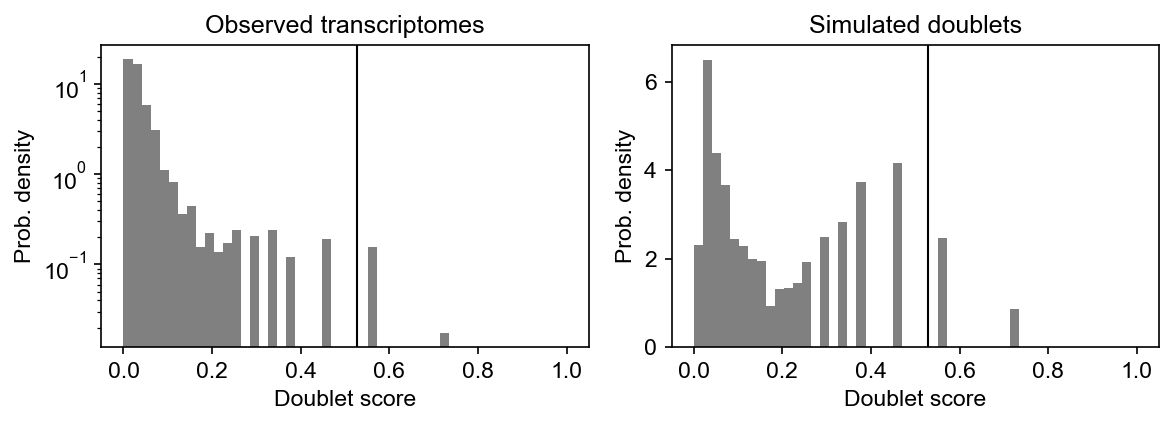

In [6]:
scrub.plot_histogram()

(<Figure size 600x300 with 3 Axes>,
 array([<matplotlib.axes._subplots.AxesSubplot object at 0x7fb59c2ae668>,
       dtype=object))

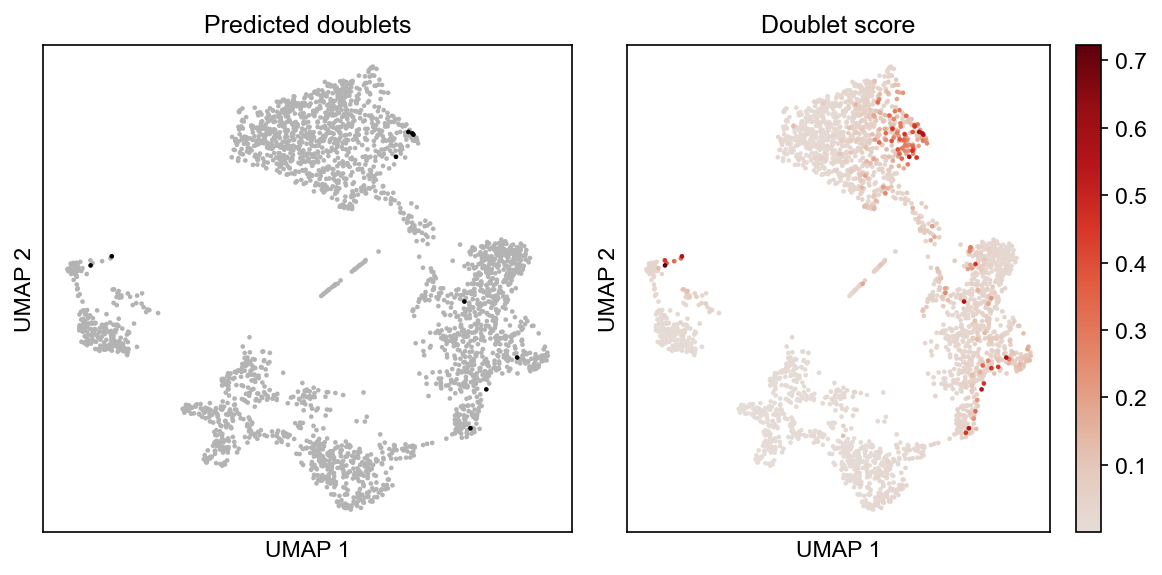

In [7]:
scrub.set_embedding('UMAP', scr.get_umap(scrub.manifold_obs_, 10, min_dist=0.3))
scrub.plot_embedding('UMAP', order_points=True)

In [8]:
adata1.obs['doublet_score'] = scrub.doublet_scores_obs_

In [9]:
clf = doubletdetection.BoostClassifier(n_iters=50, use_phenograph=False, standard_scaling=True)
doublets = clf.fit(adata1.X).predict(p_thresh=1e-16, voter_thresh=0.5)

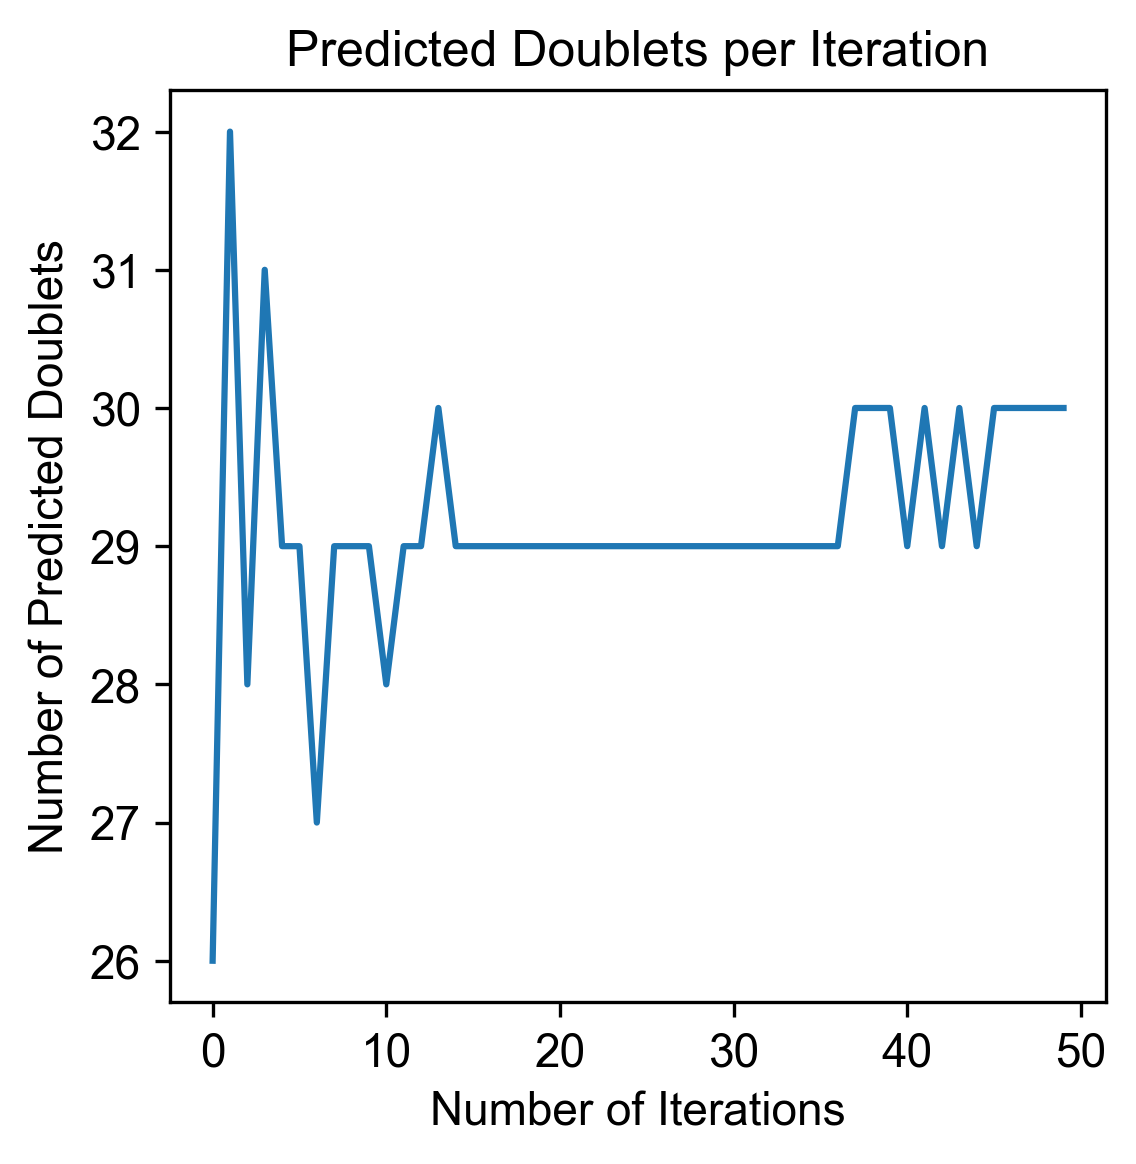

In [10]:
f = doubletdetection.plot.convergence(clf, show=True, p_thresh=1e-16, voter_thresh=0.5)

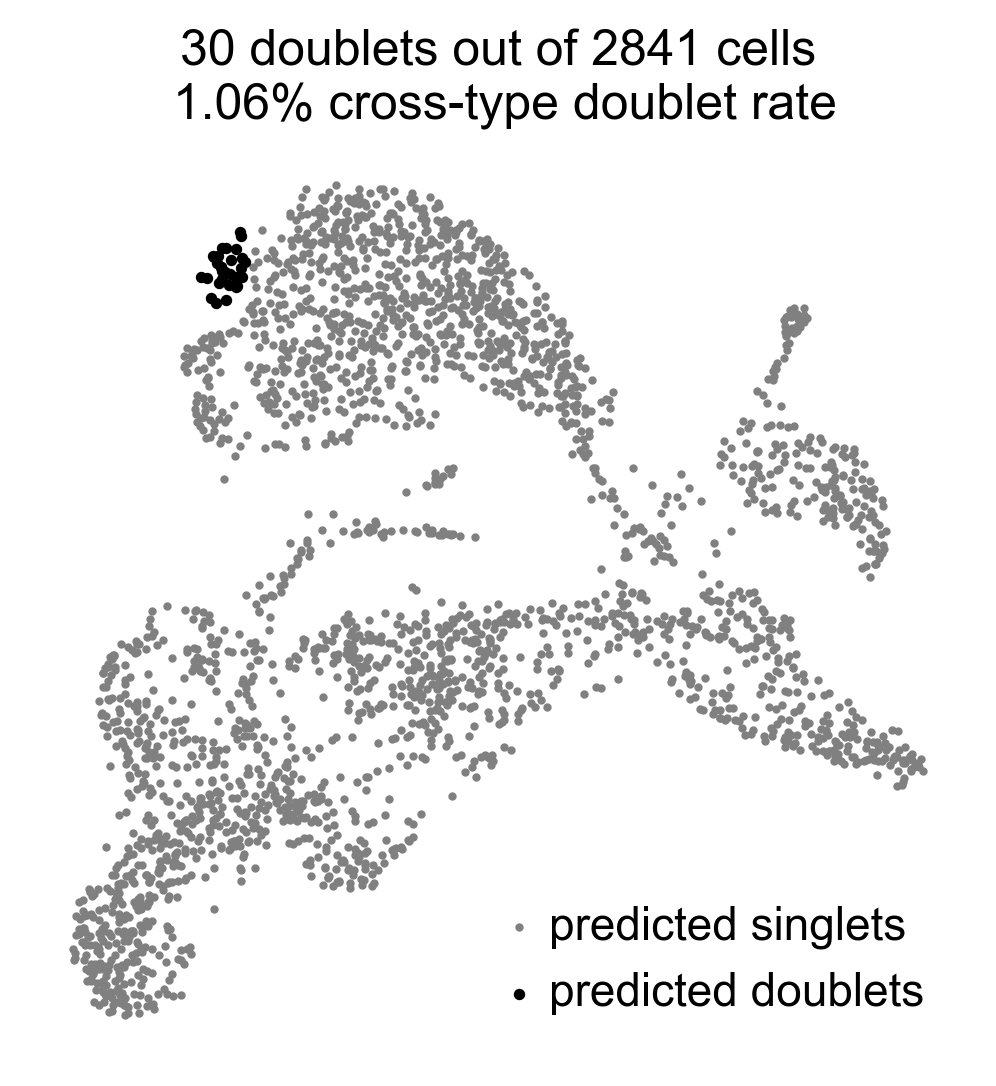

In [11]:
f2, umap_coords = doubletdetection.plot.umap_plot(adata1.X, doublets, random_state=1, show=True)

In [12]:
adata1.obs['doublet'] = list(map(str, map(int, doublets)))

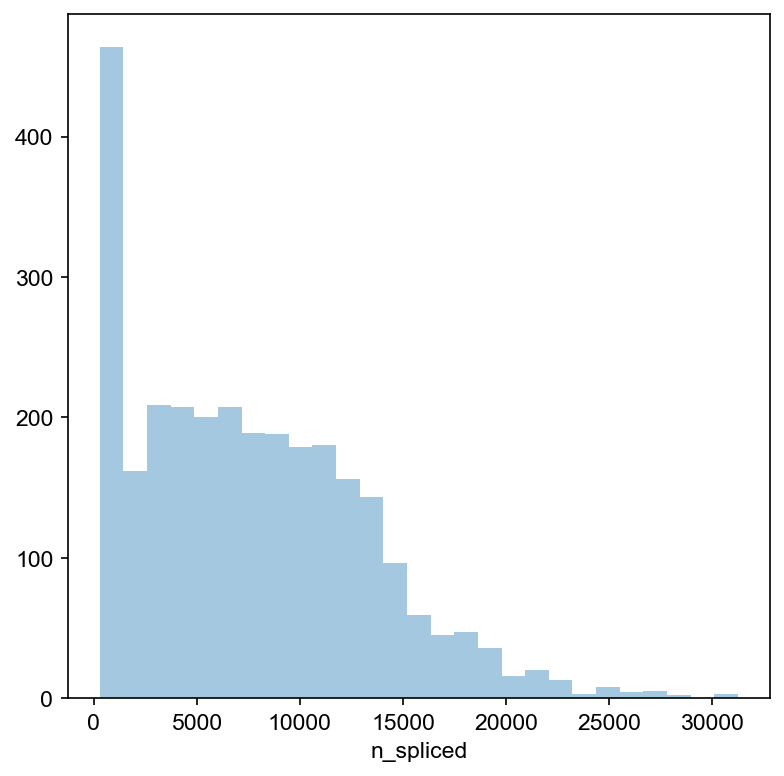

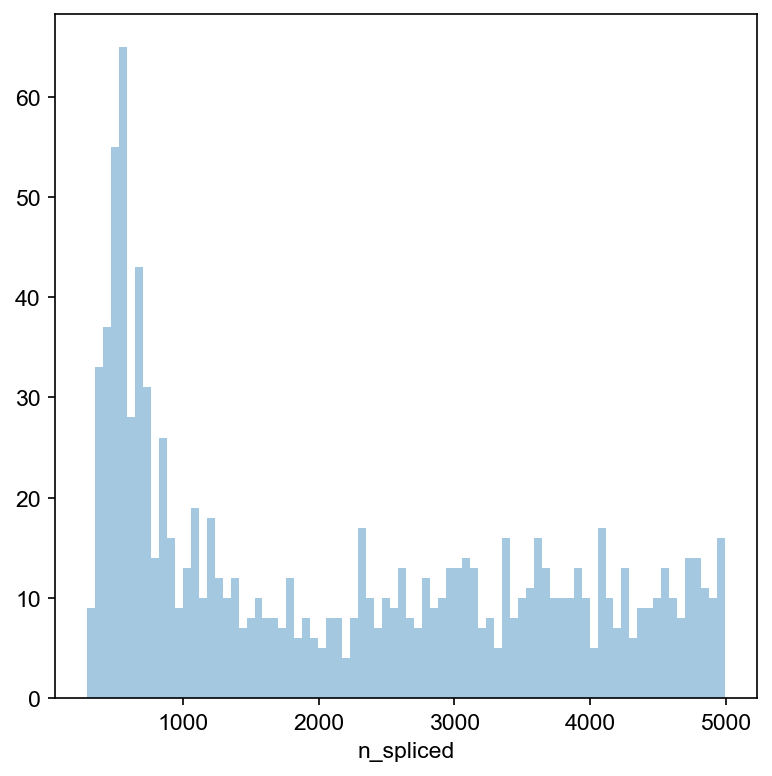

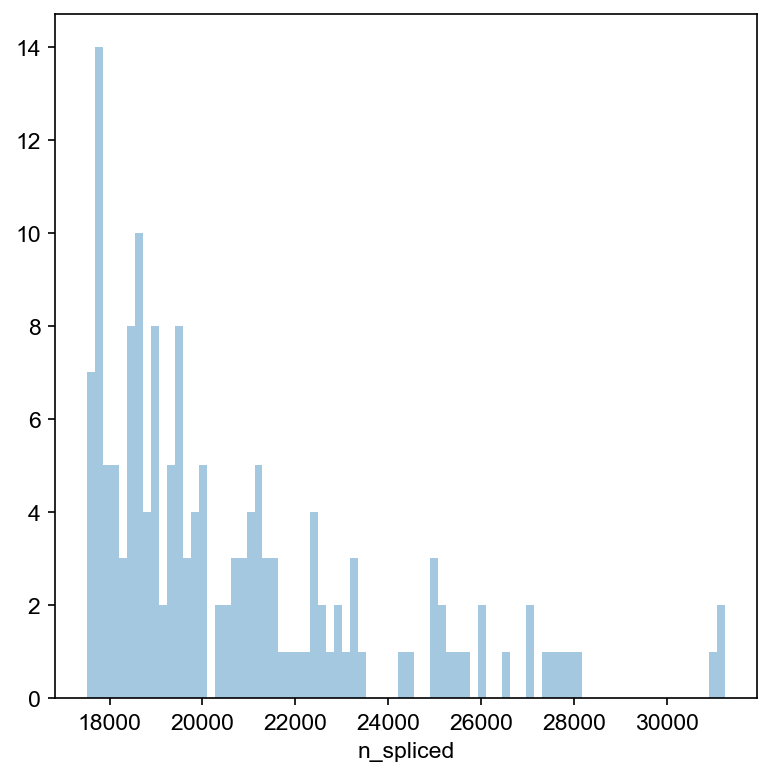

In [13]:
#Thresholding decision: spliced counts
ax=sb.distplot(adata1.obs['n_spliced'], kde=False)
plt.show()

ax=sb.distplot(adata1.obs['n_spliced'][adata1.obs['n_spliced']<5000], kde=False, bins=80)
plt.show()

ax=sb.distplot(adata1.obs['n_spliced'][adata1.obs['n_spliced']>17500], kde=False, bins=80)
plt.show()

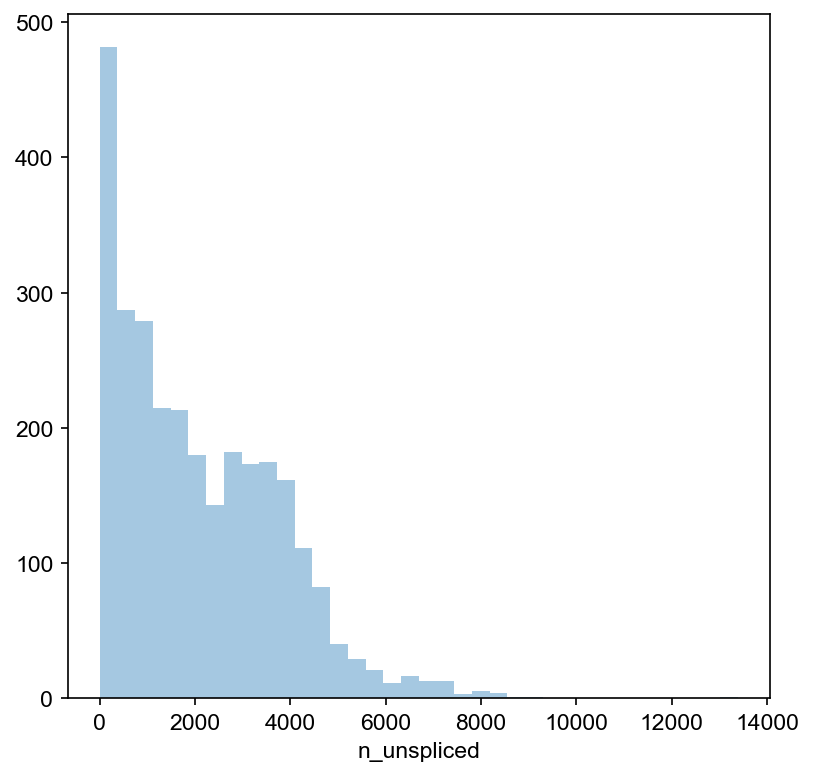

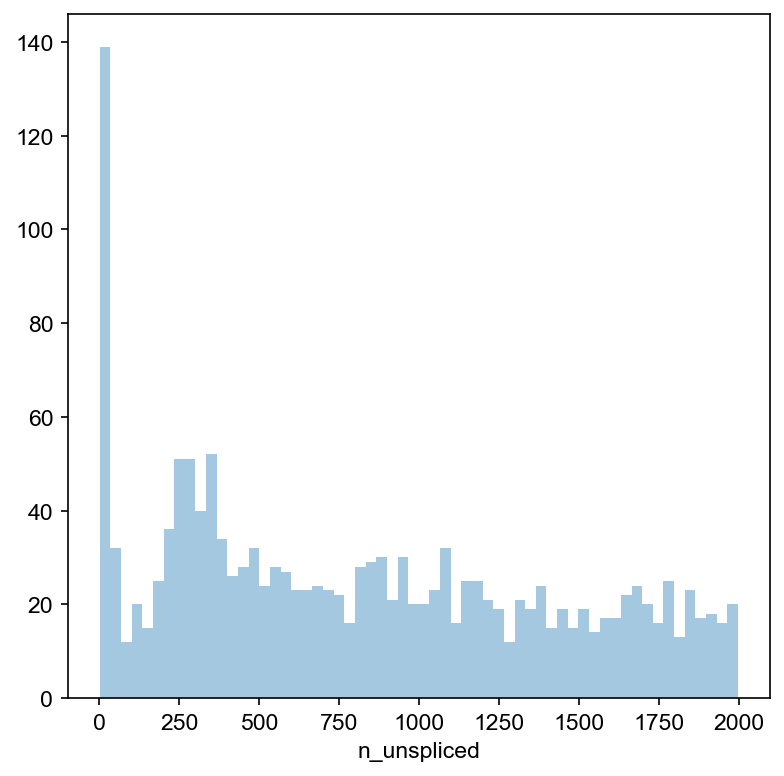

In [14]:
#Thresholding decision: unspliced counts
ax=sb.distplot(adata1.obs['n_unspliced'], kde=False)
plt.show()

ax=sb.distplot(adata1.obs['n_unspliced'][adata1.obs['n_unspliced']<2000], kde=False, bins=60)
plt.show()

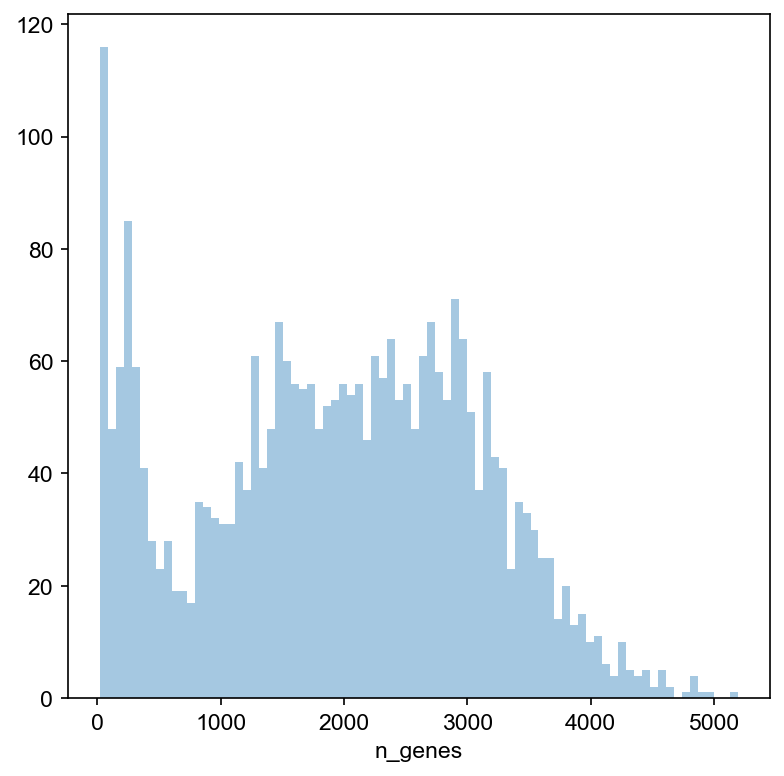

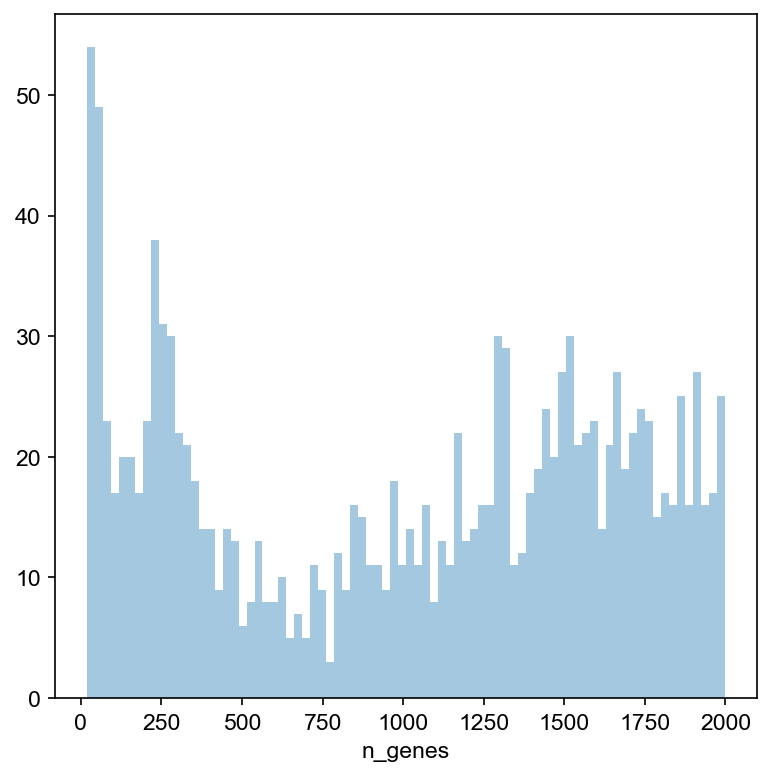

In [15]:
#Thresholding decision: genes
ax=sb.distplot(adata1.obs['n_genes'], kde=False, bins=80)
plt.show()
ax=sb.distplot(adata1.obs['n_genes'][adata1.obs['n_genes']<2000], kde=False, bins=80)
plt.show()

In [16]:
print("Cells before filtering: ", len(adata1.obs_names), "\n")

sc.pp.filter_cells(adata1, min_counts=2000)
sc.pp.filter_cells(adata1, max_counts=23500)
adata1 = adata1[adata1.obs['n_unspliced']>750]
sc.pp.filter_cells(adata1, min_genes=750)

print("Cells after filtering: ", len(adata1.obs_names))

Cells before filtering:  2841 



Trying to set attribute `.obs` of view, copying.


Cells after filtering:  1873


... storing 'doublet' as categorical


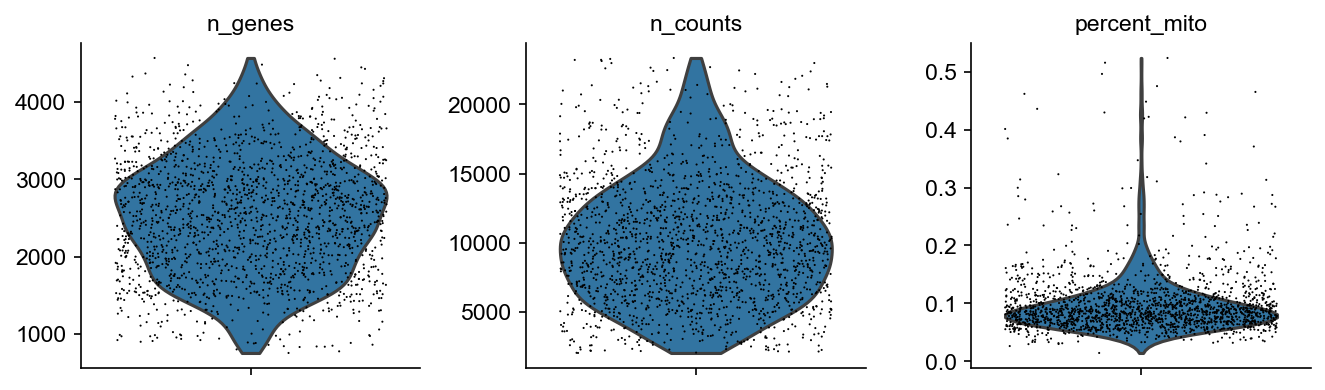

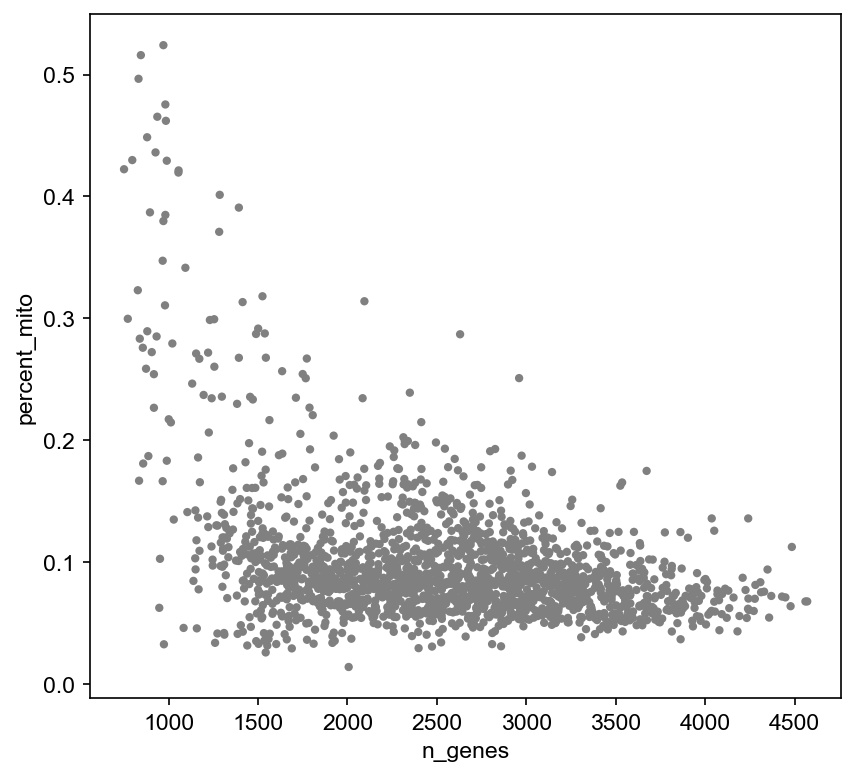

In [17]:
sc.pl.violin(adata1, ['n_genes', 'n_counts', 'percent_mito'],
             jitter=0.4, multi_panel=True)
sc.pl.scatter(adata1, 'n_genes', 'percent_mito')

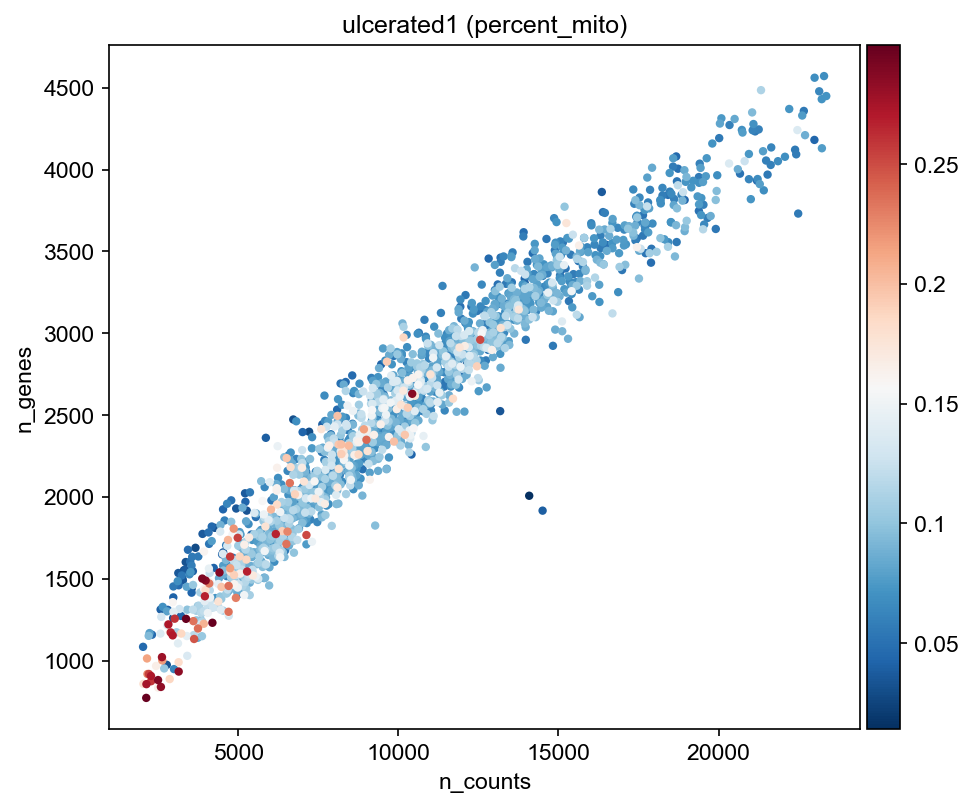

View of AnnData object with n_obs × n_vars = 1847 × 33538
    obs: 'n_counts', 'log_counts', 'n_spliced', 'n_unspliced', 'n_genes', 'percent_mito', 'percent_ribo', 'doublet_score', 'doublet'
    layers: 'matrix', 'spliced', 'unspliced'


In [18]:
adata1 = adata1[adata1.obs['percent_mito'] < 0.3, :]
sc.pl.scatter(adata1, 'n_counts', 'n_genes', color='percent_mito', title='ulcerated1 (percent_mito)')
print(adata1)

Trying to set attribute `.uns` of view, copying.


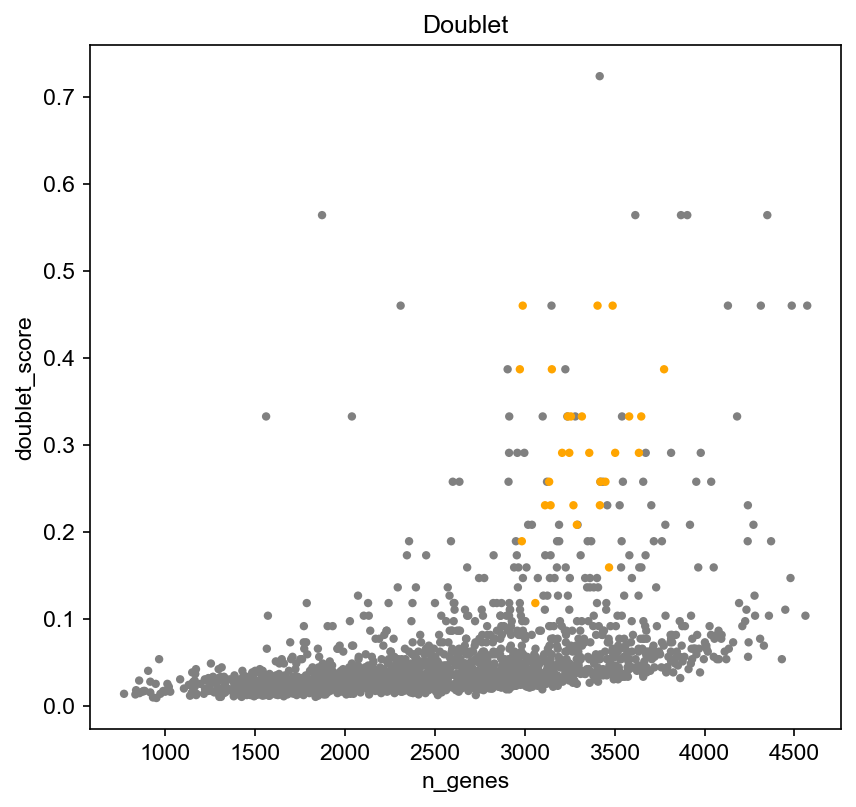

In [19]:
sc.pl.scatter(adata1, 'n_genes', 'doublet_score', color='doublet', palette=['gray', 'orange'], legend_loc='none', title='Doublet')
adata1 = adata1[adata1.obs['doublet'] != '1']
adata1 = adata1[adata1.obs['doublet_score'] < 0.3]

In [20]:
print(adata1)

View of AnnData object with n_obs × n_vars = 1798 × 33538
    obs: 'n_counts', 'log_counts', 'n_spliced', 'n_unspliced', 'n_genes', 'percent_mito', 'percent_ribo', 'doublet_score', 'doublet'
    uns: 'doublet_colors'
    layers: 'matrix', 'spliced', 'unspliced'


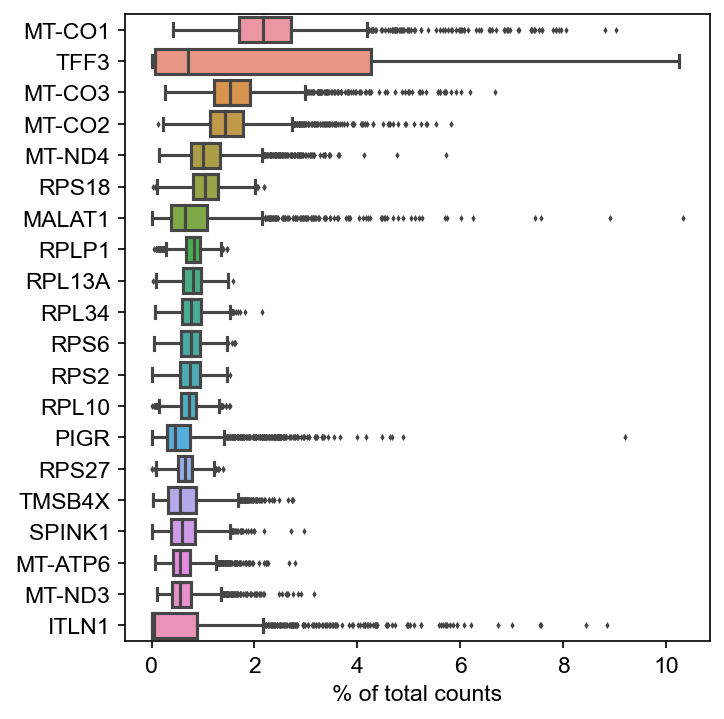

In [21]:
sc.pl.highest_expr_genes(adata1, n_top=20)

##### 2.2 ulcerated2 QC

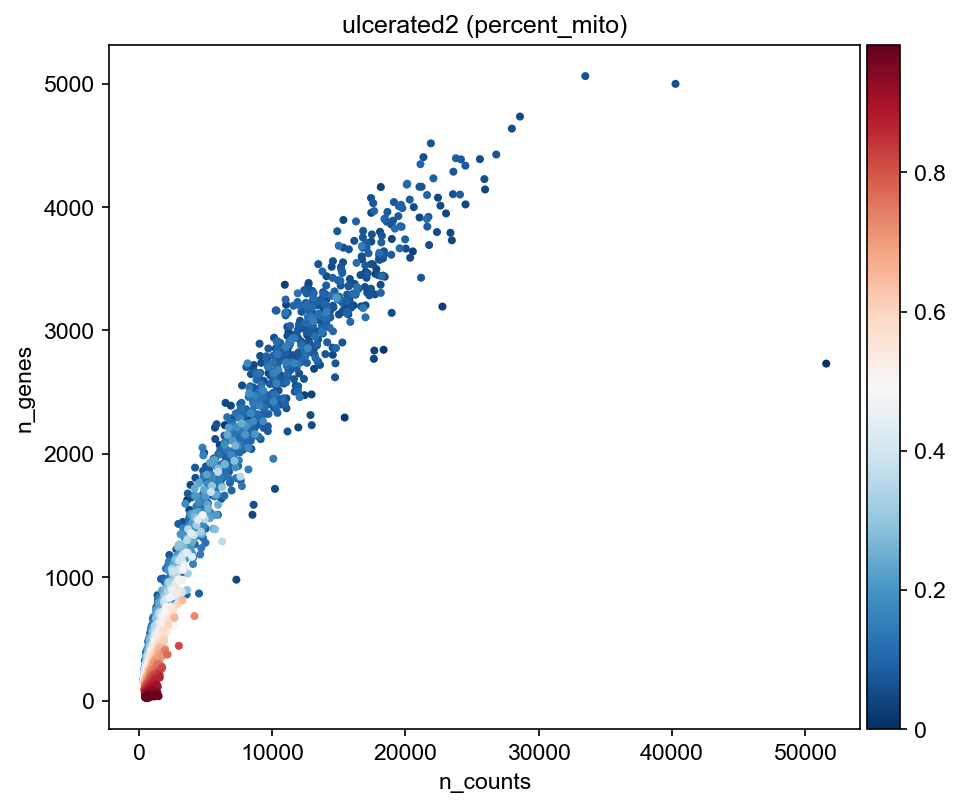

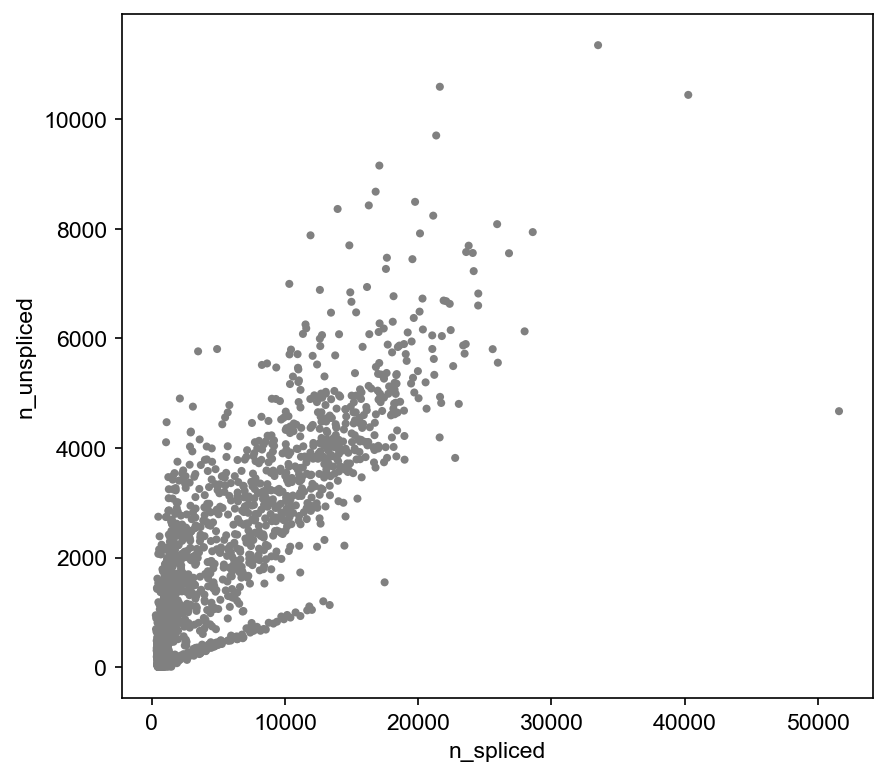

In [22]:
# Calculate QC covariates
adata2.obs['n_counts'] = adata2.X.sum(1)
adata2.obs['log_counts'] = np.log(adata2.obs['n_counts'])
adata2.obs['n_spliced'] = adata2.layers['spliced'].sum(1)
adata2.obs['n_unspliced'] = adata2.layers['unspliced'].sum(1)
adata2.obs['n_genes'] = (adata2.X > 0).sum(1)
# Compute for each cell the fraction of counts in mito genes vs. all genes
mito_genes = adata2.var_names.str.startswith('MT-')
adata2.obs['percent_mito'] = np.sum(
    adata2[:, mito_genes].X, axis=1) / np.sum(adata2.X, axis=1)
# Compute for each cell the fraction of counts in ribosomal genes vs. all genes
ribo_genes = adata2.var_names.str.startswith('RP')
adata2.obs['percent_ribo'] = np.sum(
    adata2[:, ribo_genes].X, axis=1) / np.sum(adata2.X, axis=1)

sc.pl.scatter(adata2, 'n_counts', 'n_genes', color='percent_mito', title='ulcerated2 (percent_mito)')
sc.pl.scatter(adata2, 'n_spliced', 'n_unspliced')

In [23]:
# Doublet analysis
scrub = scr.Scrublet(adata2.X, expected_doublet_rate=0.06)
doublet_scores, predicted_doublets = scrub.scrub_doublets(min_counts=2, 
                                                          min_cells=3, 
                                                          min_gene_variability_pctl=85, 
                                                          n_prin_comps=30,
                                                          mean_center=False, 
                                                          normalize_variance=False,
                                                          log_transform=True)

Preprocessing...
Simulating doublets...
Embedding transcriptomes using Truncated SVD...
Calculating doublet scores...
Automatically set threshold at doublet score = 0.47
Detected doublet rate = 0.0%
Estimated detectable doublet fraction = 1.7%
Overall doublet rate:
	Expected   = 6.0%
	Estimated  = 3.0%
Elapsed time: 0.9 seconds


(<Figure size 600x225 with 2 Axes>,
 array([<matplotlib.axes._subplots.AxesSubplot object at 0x7fb558ad4f98>,
       dtype=object))

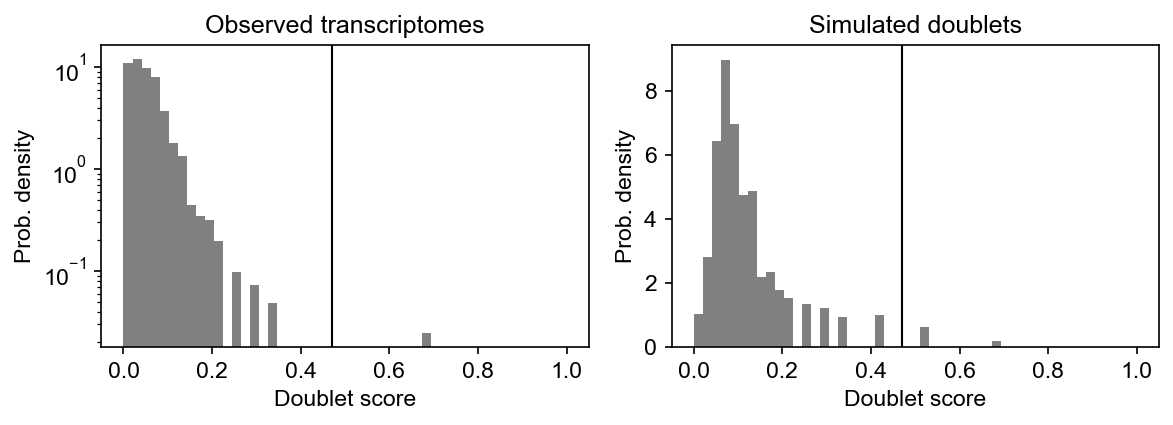

In [24]:
scrub.plot_histogram()

(<Figure size 600x300 with 3 Axes>,
 array([<matplotlib.axes._subplots.AxesSubplot object at 0x7fb59c3eb5f8>,
       dtype=object))

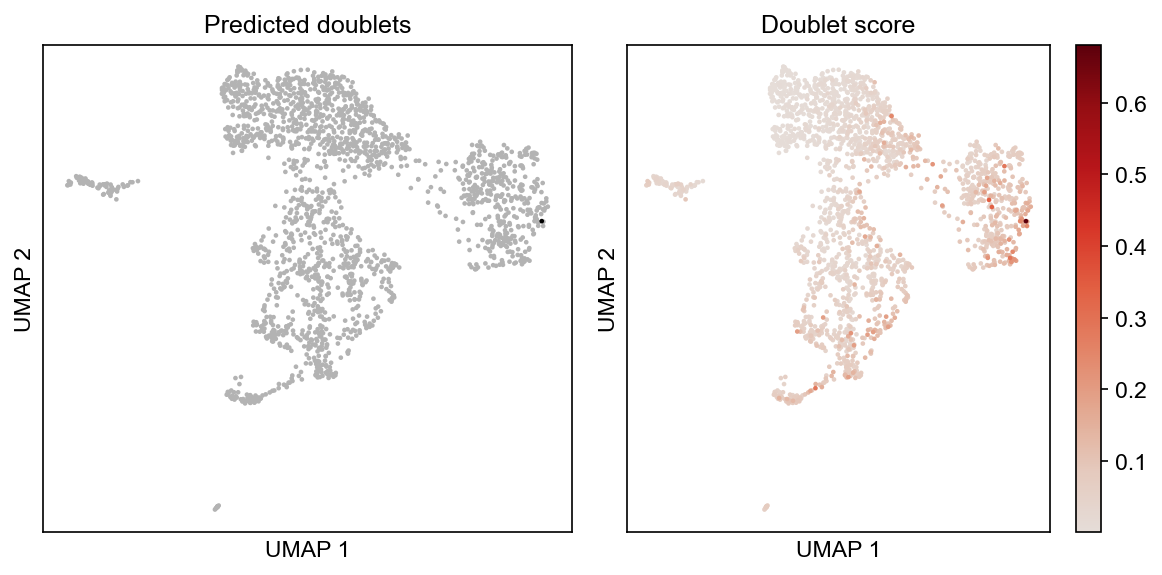

In [25]:
scrub.set_embedding('UMAP', scr.get_umap(scrub.manifold_obs_, 10, min_dist=0.3))
scrub.plot_embedding('UMAP', order_points=True)

In [26]:
adata2.obs['doublet_score'] = scrub.doublet_scores_obs_

In [27]:
clf = doubletdetection.BoostClassifier(n_iters=50, use_phenograph=False, standard_scaling=True)
doublets = clf.fit(adata2.X).predict(p_thresh=1e-16, voter_thresh=0.5)

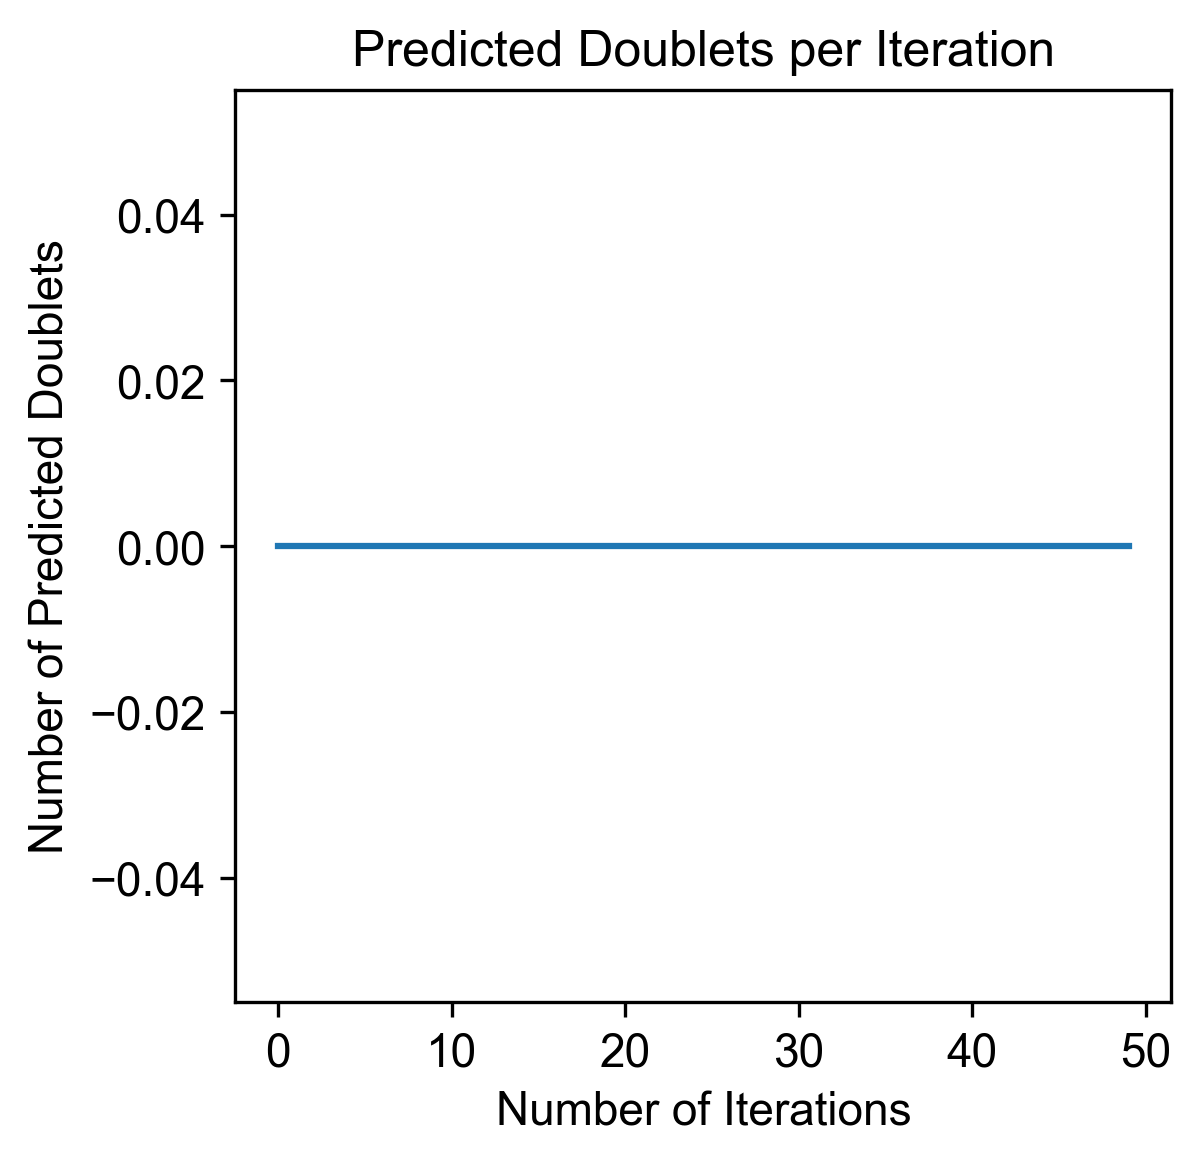

In [28]:
f = doubletdetection.plot.convergence(clf, show=True, p_thresh=1e-16, voter_thresh=0.5)

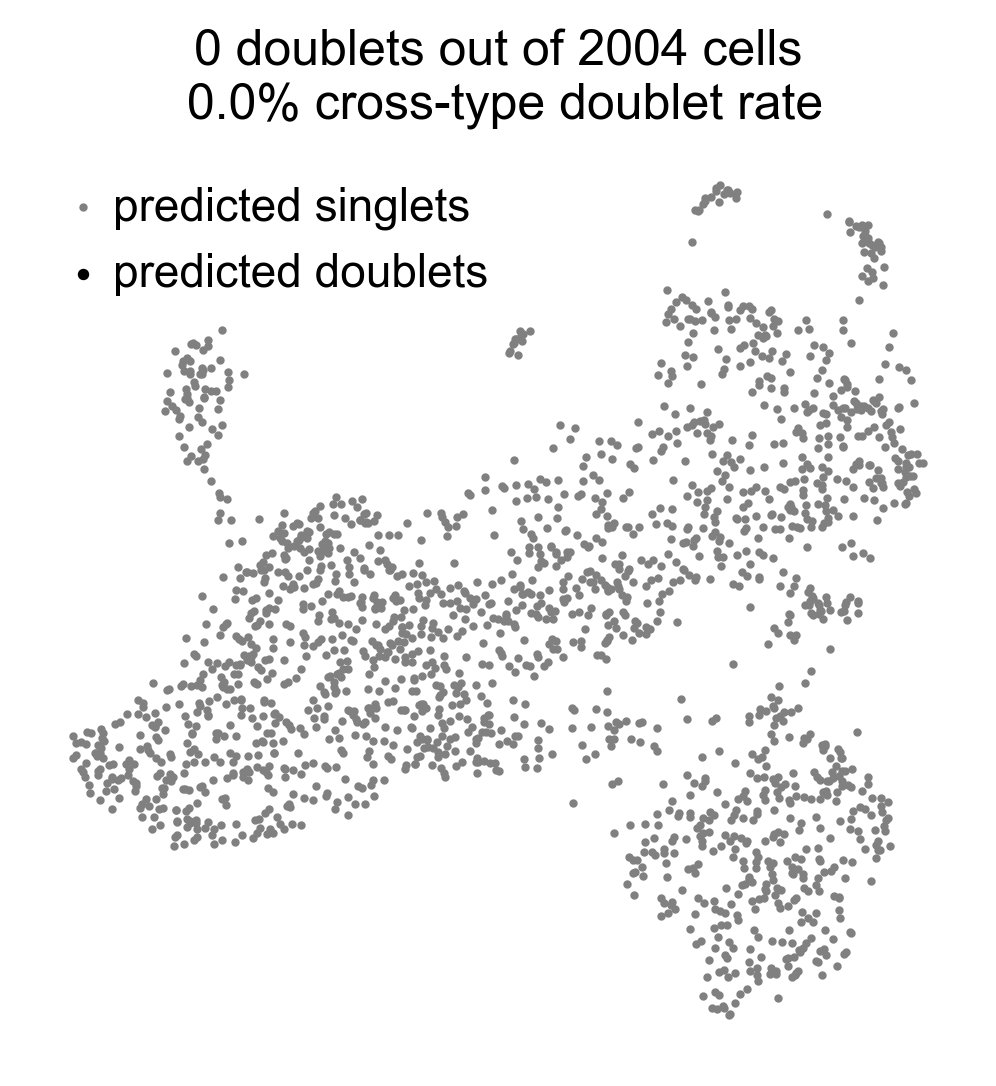

In [29]:
f2, umap_coords = doubletdetection.plot.umap_plot(adata2.X, doublets, random_state=1, show=True)

In [30]:
adata2.obs['doublet'] = list(map(str, map(int, doublets)))

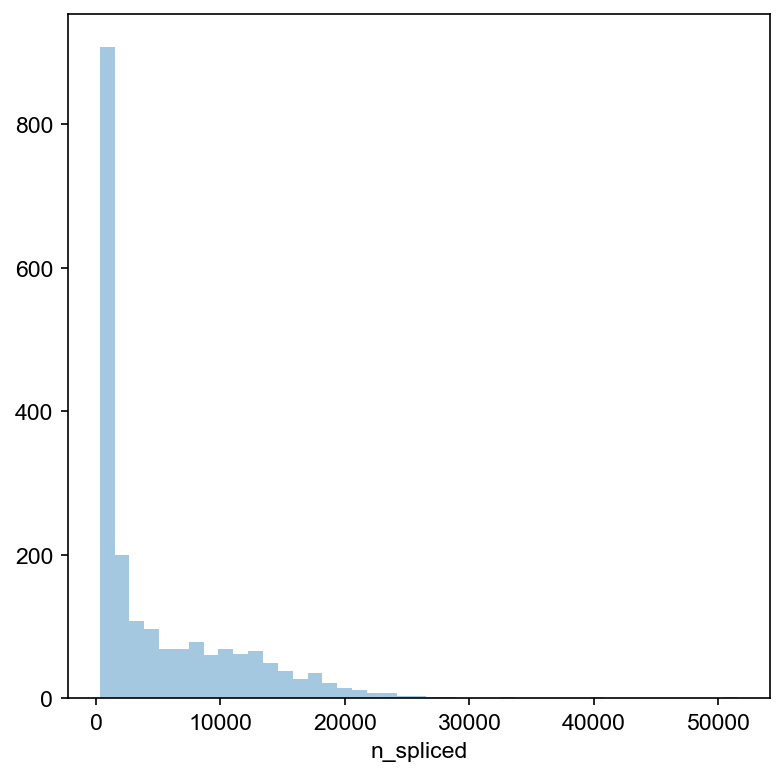

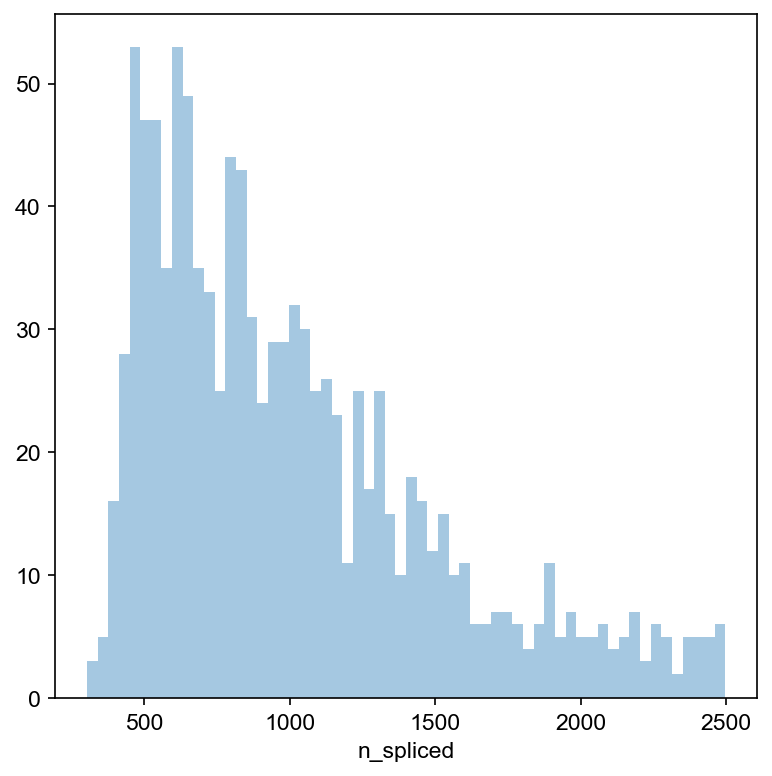

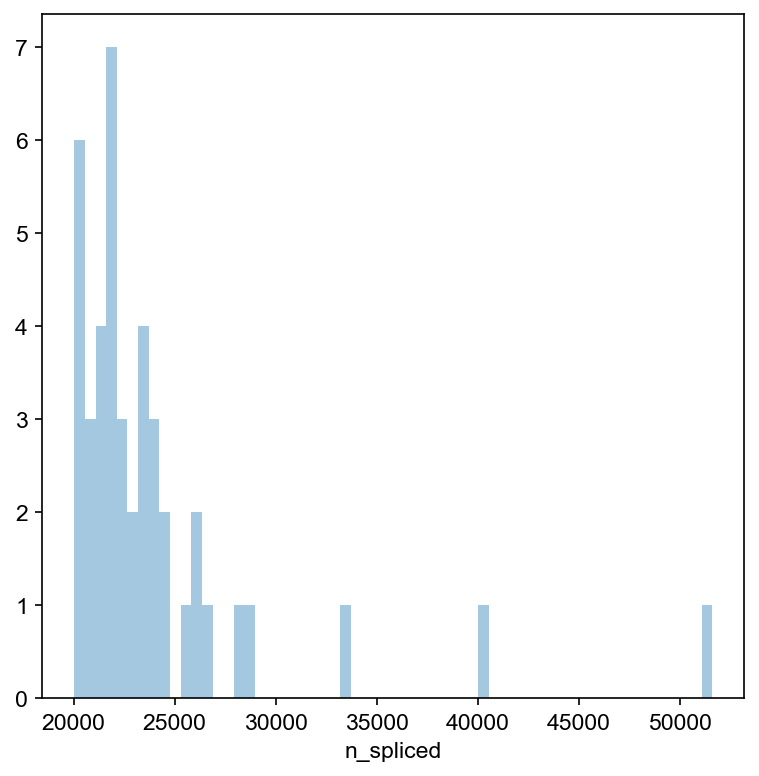

In [31]:
#Thresholding decision: spliced counts
ax=sb.distplot(adata2.obs['n_spliced'], kde=False)
plt.show()

ax=sb.distplot(adata2.obs['n_spliced'][adata2.obs['n_counts']<2500], kde=False, bins=60)
plt.show()

ax=sb.distplot(adata2.obs['n_spliced'][adata2.obs['n_counts']>20000], kde=False, bins=60)
plt.show()

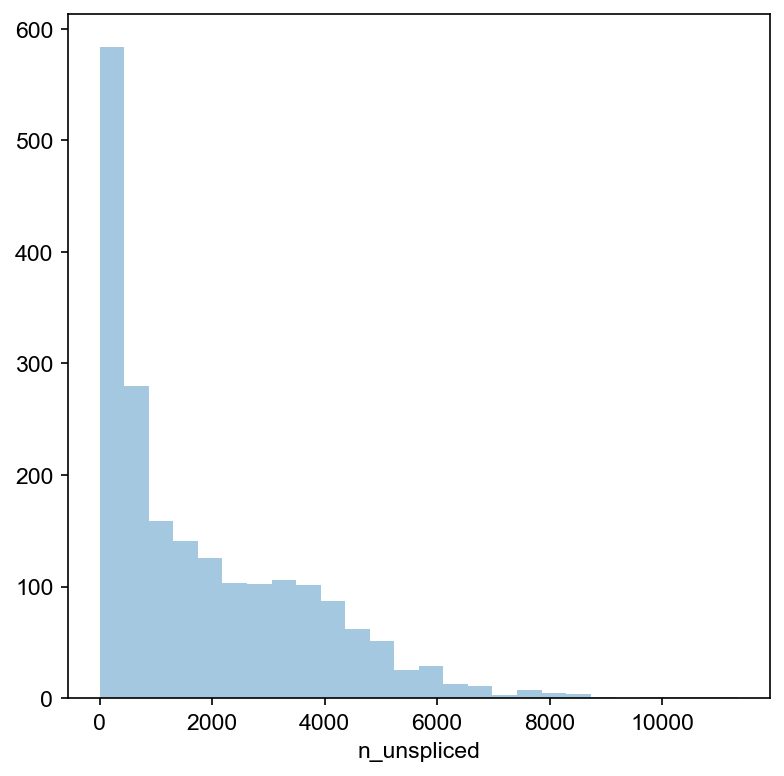

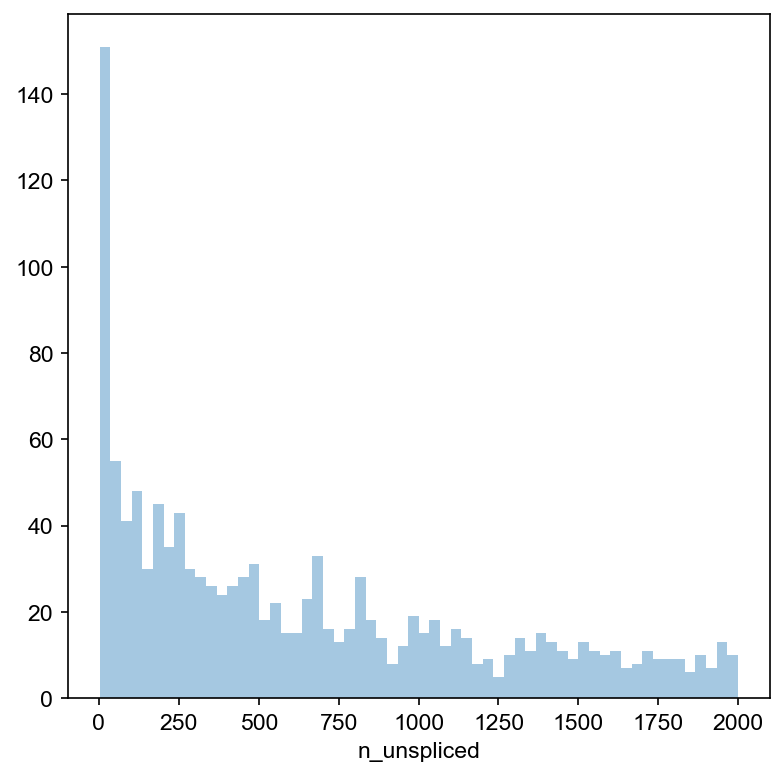

In [32]:
#Thresholding decision: unspliced counts
ax=sb.distplot(adata2.obs['n_unspliced'], kde=False)
plt.show()

ax=sb.distplot(adata2.obs['n_unspliced'][adata2.obs['n_unspliced']<2000], kde=False, bins=60)
plt.show()

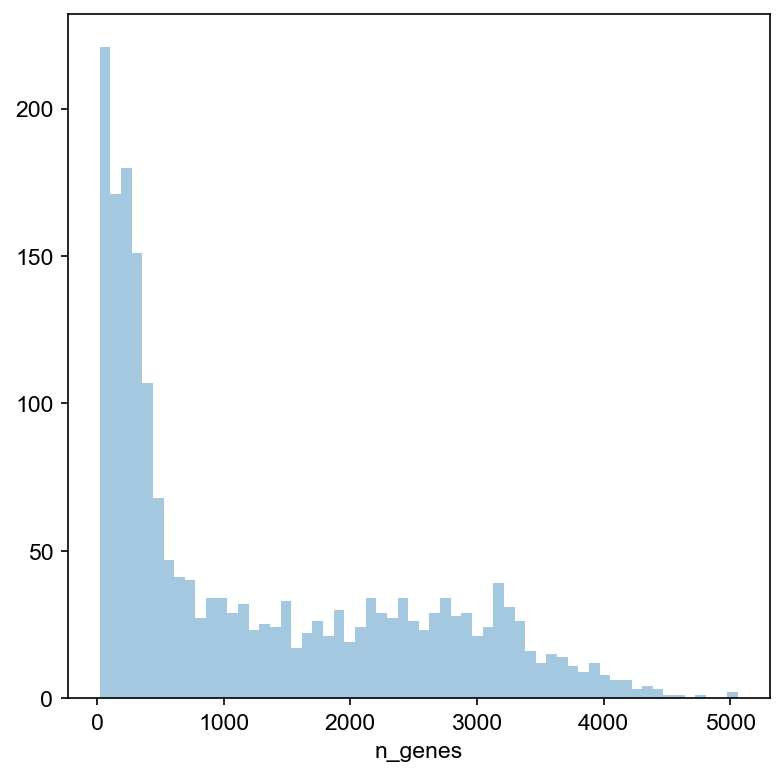

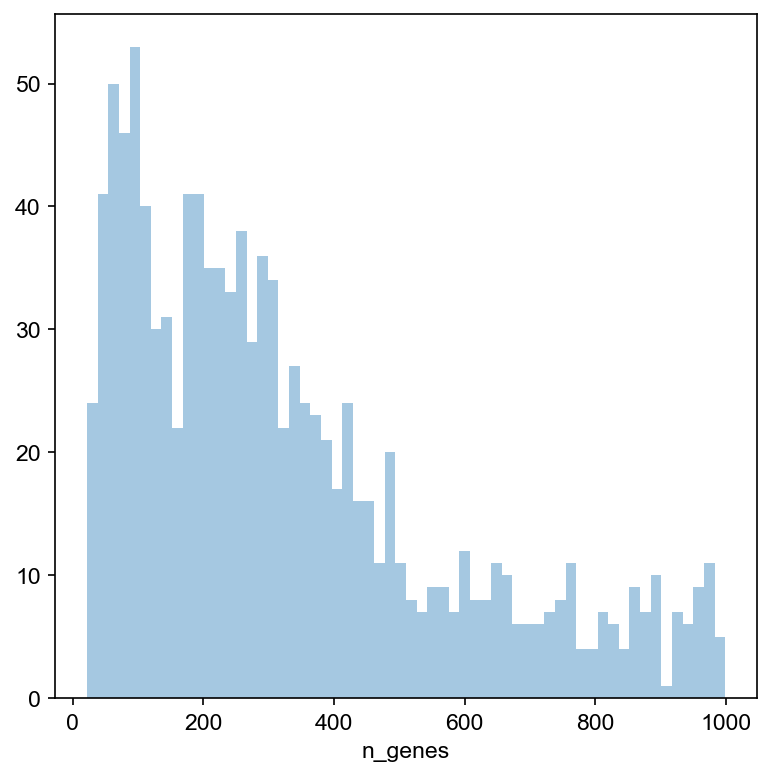

In [33]:
#Thresholding decision: genes
ax=sb.distplot(adata2.obs['n_genes'], kde=False, bins=60)
plt.show()
ax=sb.distplot(adata2.obs['n_genes'][adata2.obs['n_genes']<1000], kde=False, bins=60)
plt.show()

In [34]:
print("Cells before filtering: ", len(adata2.obs_names), "\n")

sc.pp.filter_cells(adata2, min_counts=1600)
sc.pp.filter_cells(adata2, max_counts=27500)
adata2 = adata2[adata2.obs['n_unspliced']>900]
sc.pp.filter_cells(adata2, min_genes=500)

print("Cells after filtering: ", len(adata2.obs_names))

Trying to set attribute `.obs` of view, copying.


Cells before filtering:  2004 

Cells after filtering:  878


... storing 'doublet' as categorical


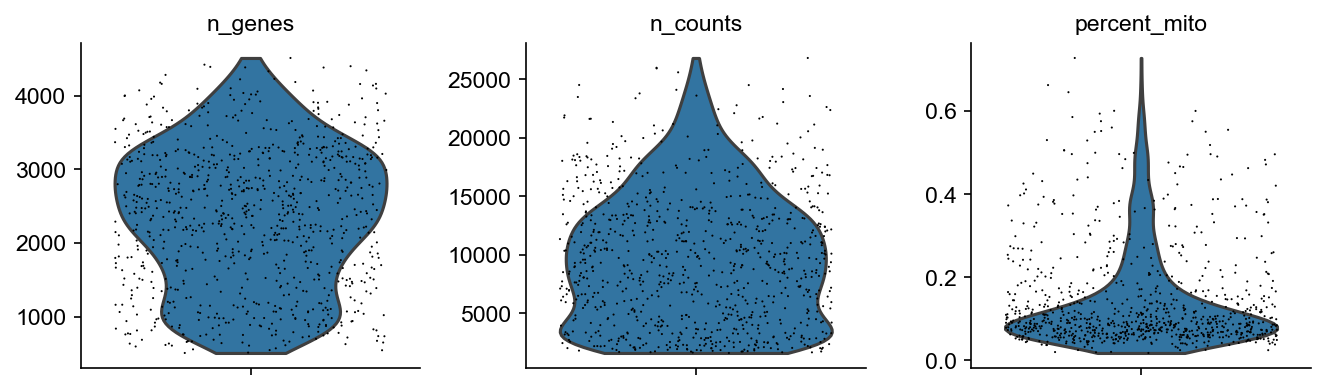

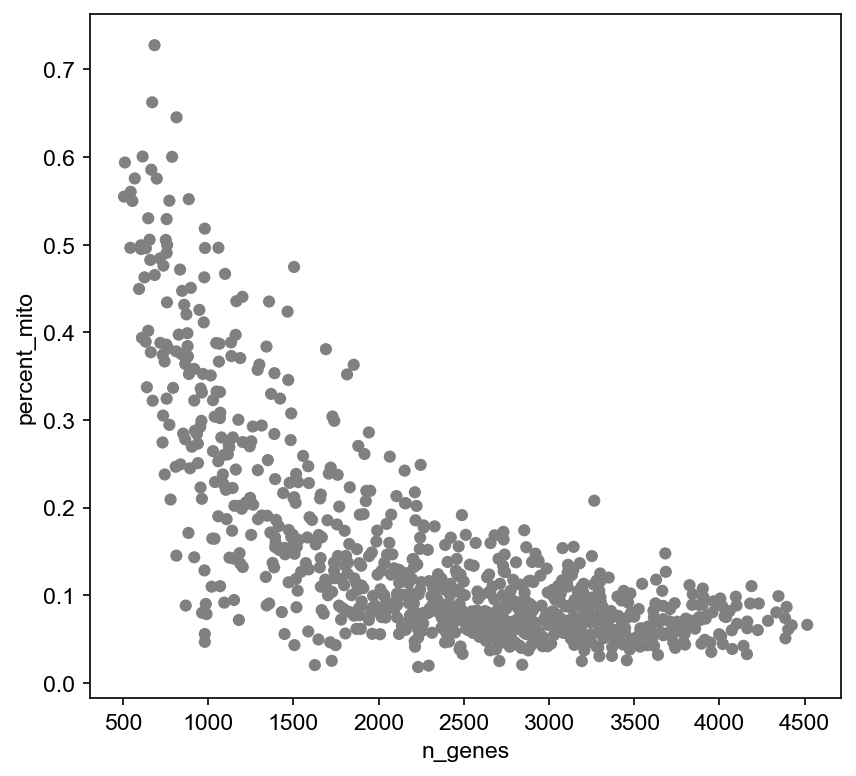

In [35]:
sc.pl.violin(adata2, ['n_genes', 'n_counts', 'percent_mito'],
             jitter=0.4, multi_panel=True)
sc.pl.scatter(adata2, 'n_genes', 'percent_mito')

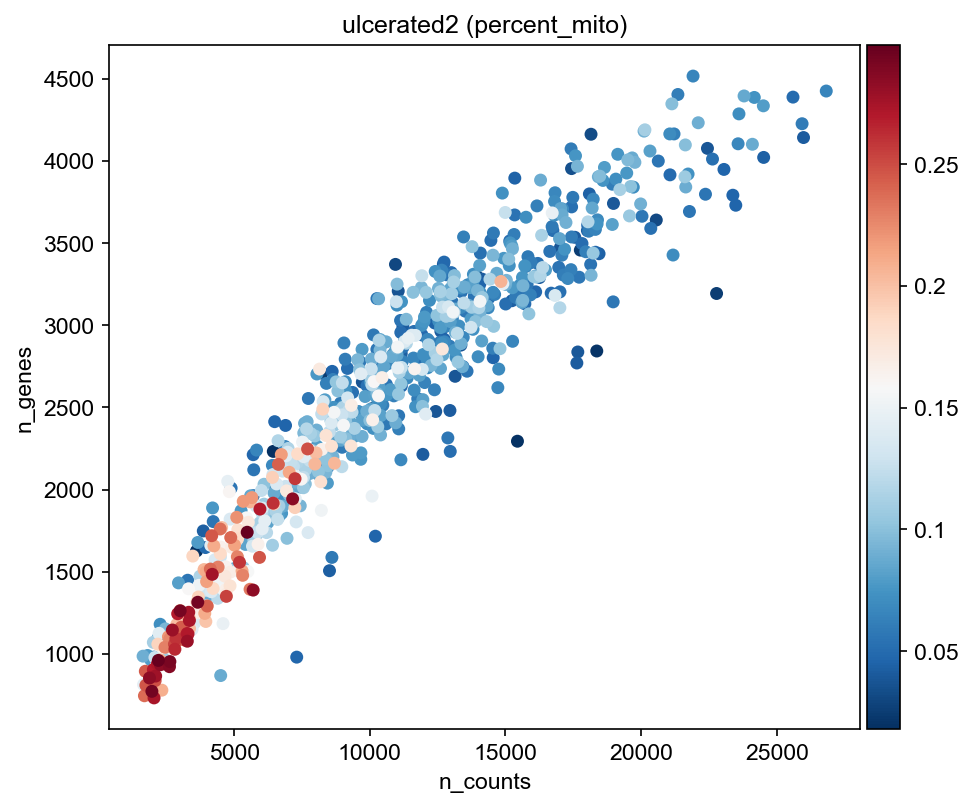

View of AnnData object with n_obs × n_vars = 775 × 33538
    obs: 'n_counts', 'log_counts', 'n_spliced', 'n_unspliced', 'n_genes', 'percent_mito', 'percent_ribo', 'doublet_score', 'doublet'
    layers: 'matrix', 'spliced', 'unspliced'


In [36]:
adata2 = adata2[adata2.obs['percent_mito'] < 0.3, :]
sc.pl.scatter(adata2, 'n_counts', 'n_genes', color='percent_mito', title='ulcerated2 (percent_mito)')
print(adata2)

Trying to set attribute `.uns` of view, copying.


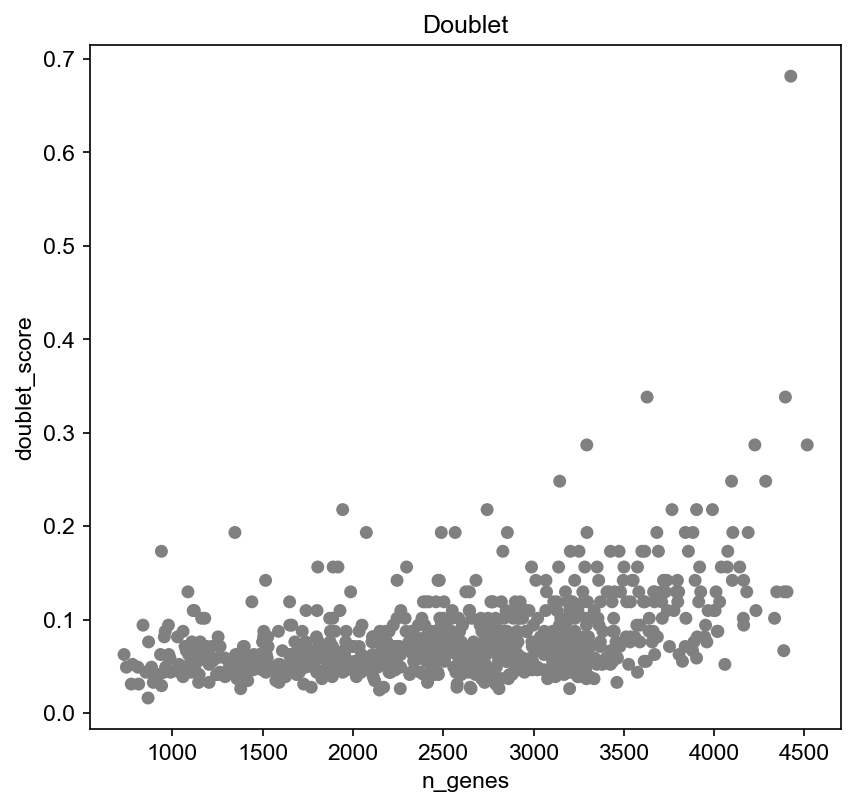

In [37]:
sc.pl.scatter(adata2, 'n_genes', 'doublet_score', color='doublet', palette=['gray', 'orange'], legend_loc='none', title='Doublet')
adata2 = adata2[adata2.obs['doublet'] != '1']
adata2 = adata2[adata2.obs['doublet_score'] < 0.3]

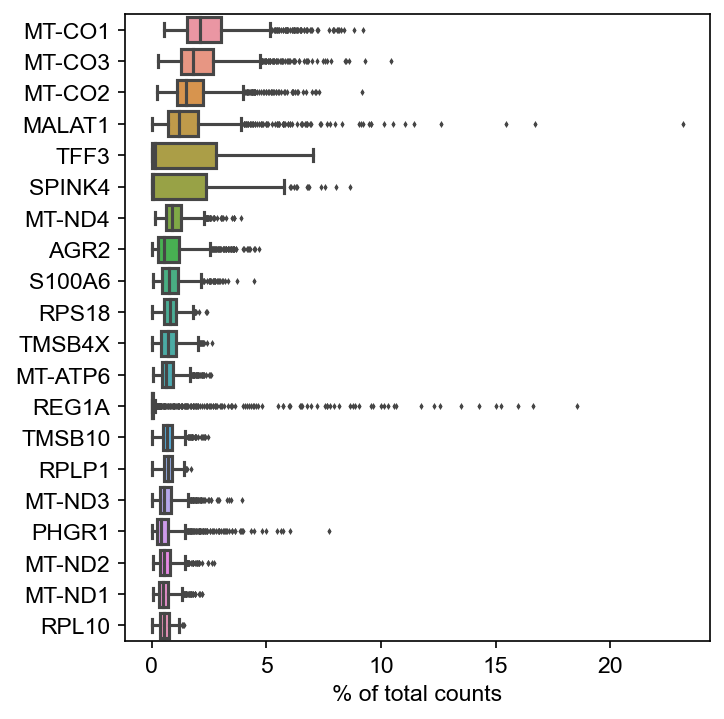

AnnData object with n_obs × n_vars = 772 × 33538
    obs: 'n_counts', 'log_counts', 'n_spliced', 'n_unspliced', 'n_genes', 'percent_mito', 'percent_ribo', 'doublet_score', 'doublet'
    uns: 'doublet_colors'
    layers: 'matrix', 'spliced', 'unspliced'


In [38]:
sc.pl.highest_expr_genes(adata2, n_top=20)
print(adata2)

##### 2.3 ulcerated3 QC

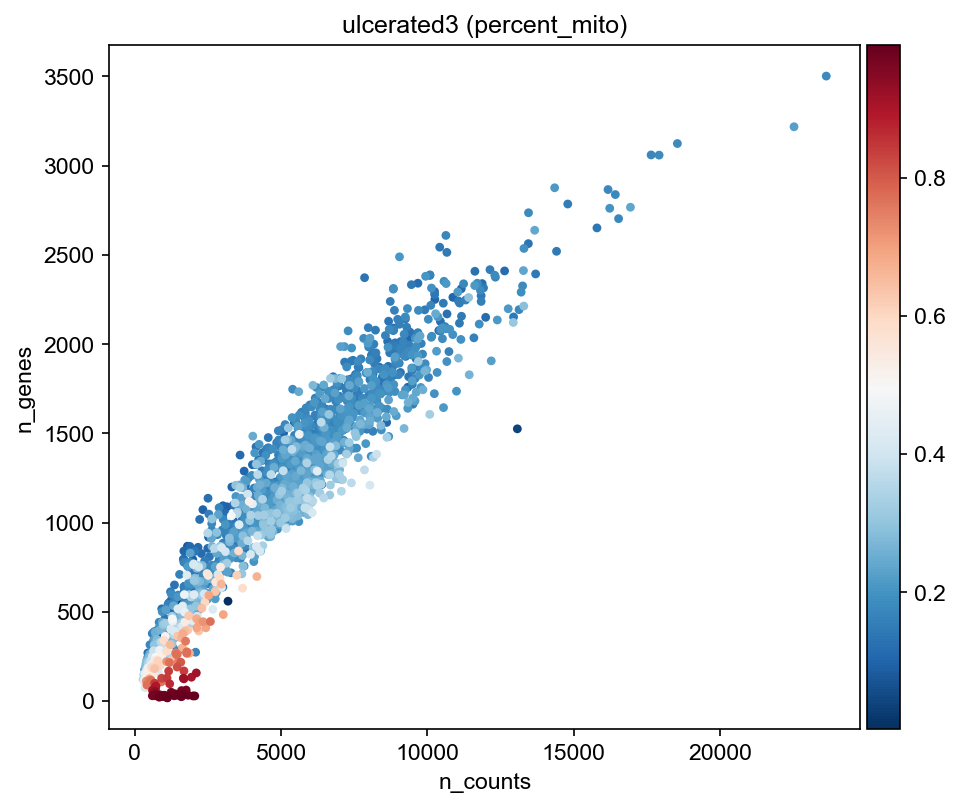

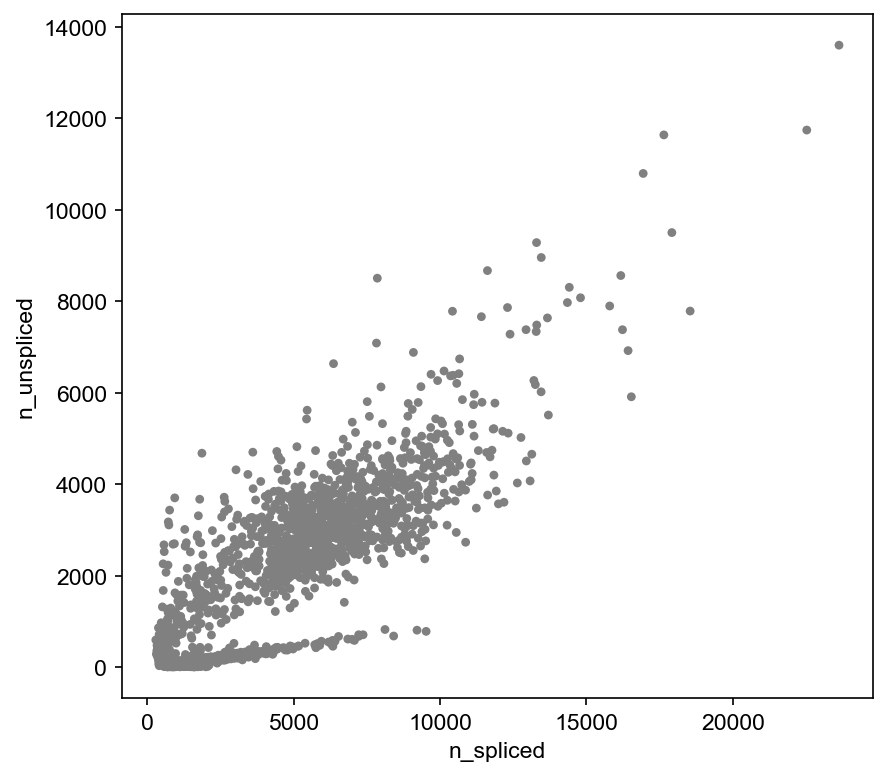

In [39]:
# Calculate QC covariates
adata3.obs['n_counts'] = adata3.X.sum(1)
adata3.obs['log_counts'] = np.log(adata3.obs['n_counts'])
adata3.obs['n_spliced'] = adata3.layers['spliced'].sum(1)
adata3.obs['n_unspliced'] = adata3.layers['unspliced'].sum(1)
adata3.obs['n_genes'] = (adata3.X > 0).sum(1)
# Compute for each cell the fraction of counts in mito genes vs. all genes
mito_genes = adata3.var_names.str.startswith('MT-')
adata3.obs['percent_mito'] = np.sum(
    adata3[:, mito_genes].X, axis=1) / np.sum(adata3.X, axis=1)
# Compute for each cell the fraction of counts in ribosomal genes vs. all genes
ribo_genes = adata3.var_names.str.startswith('RP')
adata3.obs['percent_ribo'] = np.sum(
    adata3[:, ribo_genes].X, axis=1) / np.sum(adata3.X, axis=1)

sc.pl.scatter(adata3, 'n_counts', 'n_genes', color='percent_mito', title='ulcerated3 (percent_mito)')
sc.pl.scatter(adata3, 'n_spliced', 'n_unspliced')

In [40]:
# Doublet analysis
scrub = scr.Scrublet(adata3.X, expected_doublet_rate=0.06)
doublet_scores, predicted_doublets = scrub.scrub_doublets(min_counts=2, 
                                                          min_cells=3, 
                                                          min_gene_variability_pctl=85, 
                                                          n_prin_comps=30,
                                                          mean_center=False, 
                                                          normalize_variance=False,
                                                          log_transform=True)

Preprocessing...
Simulating doublets...
Embedding transcriptomes using Truncated SVD...
Calculating doublet scores...
Automatically set threshold at doublet score = 0.44
Detected doublet rate = 0.5%
Estimated detectable doublet fraction = 10.6%
Overall doublet rate:
	Expected   = 6.0%
	Estimated  = 5.1%
Elapsed time: 0.8 seconds


(<Figure size 600x225 with 2 Axes>,
 array([<matplotlib.axes._subplots.AxesSubplot object at 0x7fb4dbd962e8>,
       dtype=object))

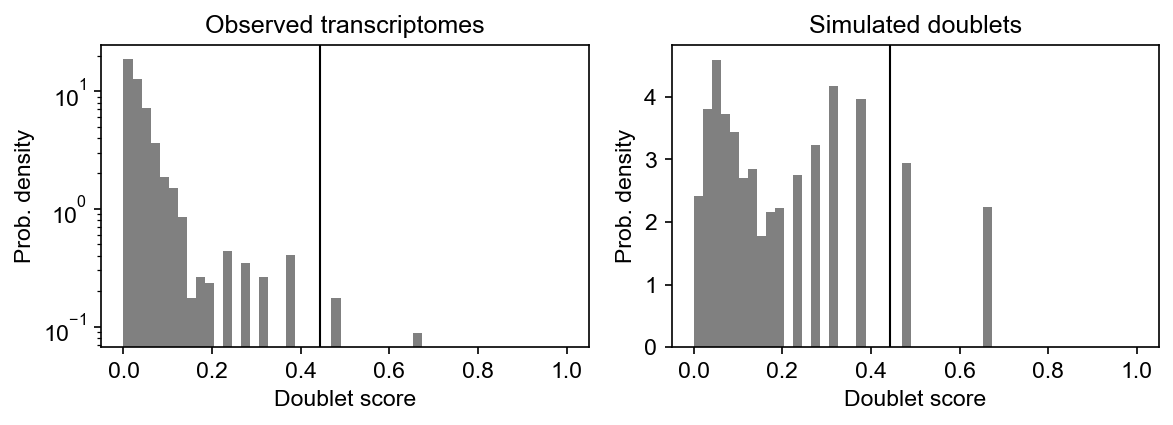

In [41]:
scrub.plot_histogram()

(<Figure size 600x300 with 3 Axes>,
 array([<matplotlib.axes._subplots.AxesSubplot object at 0x7fb59c7e6ac8>,
       dtype=object))

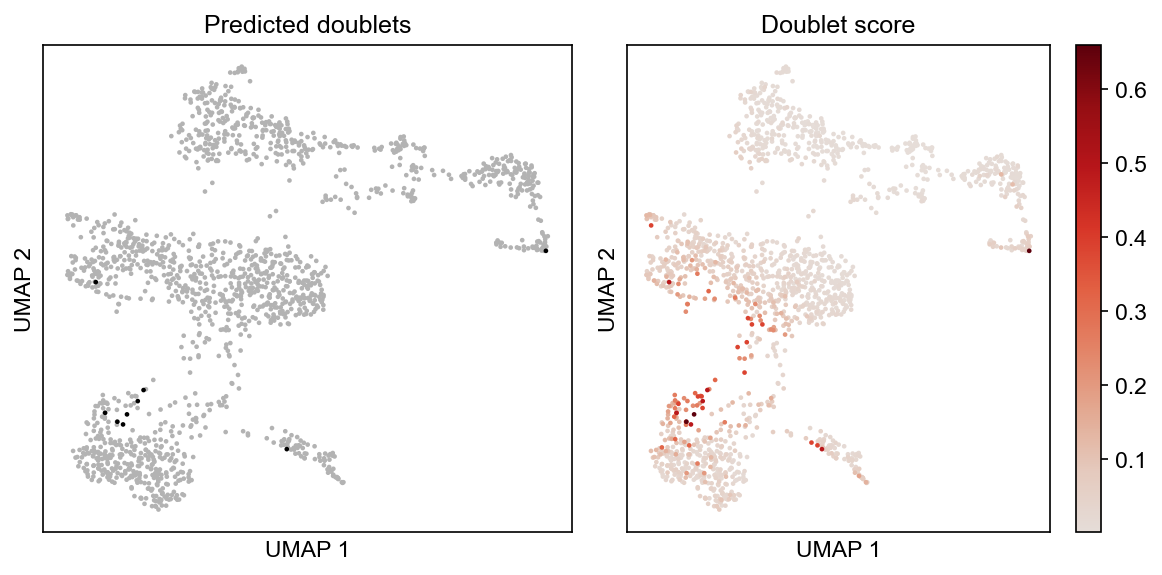

In [42]:
scrub.set_embedding('UMAP', scr.get_umap(scrub.manifold_obs_, 10, min_dist=0.3))
scrub.plot_embedding('UMAP', order_points=True)

In [43]:
adata3.obs['doublet_score'] = scrub.doublet_scores_obs_

In [44]:
clf = doubletdetection.BoostClassifier(n_iters=50, use_phenograph=False, standard_scaling=True)
doublets = clf.fit(adata3.X).predict(p_thresh=1e-16, voter_thresh=0.5)

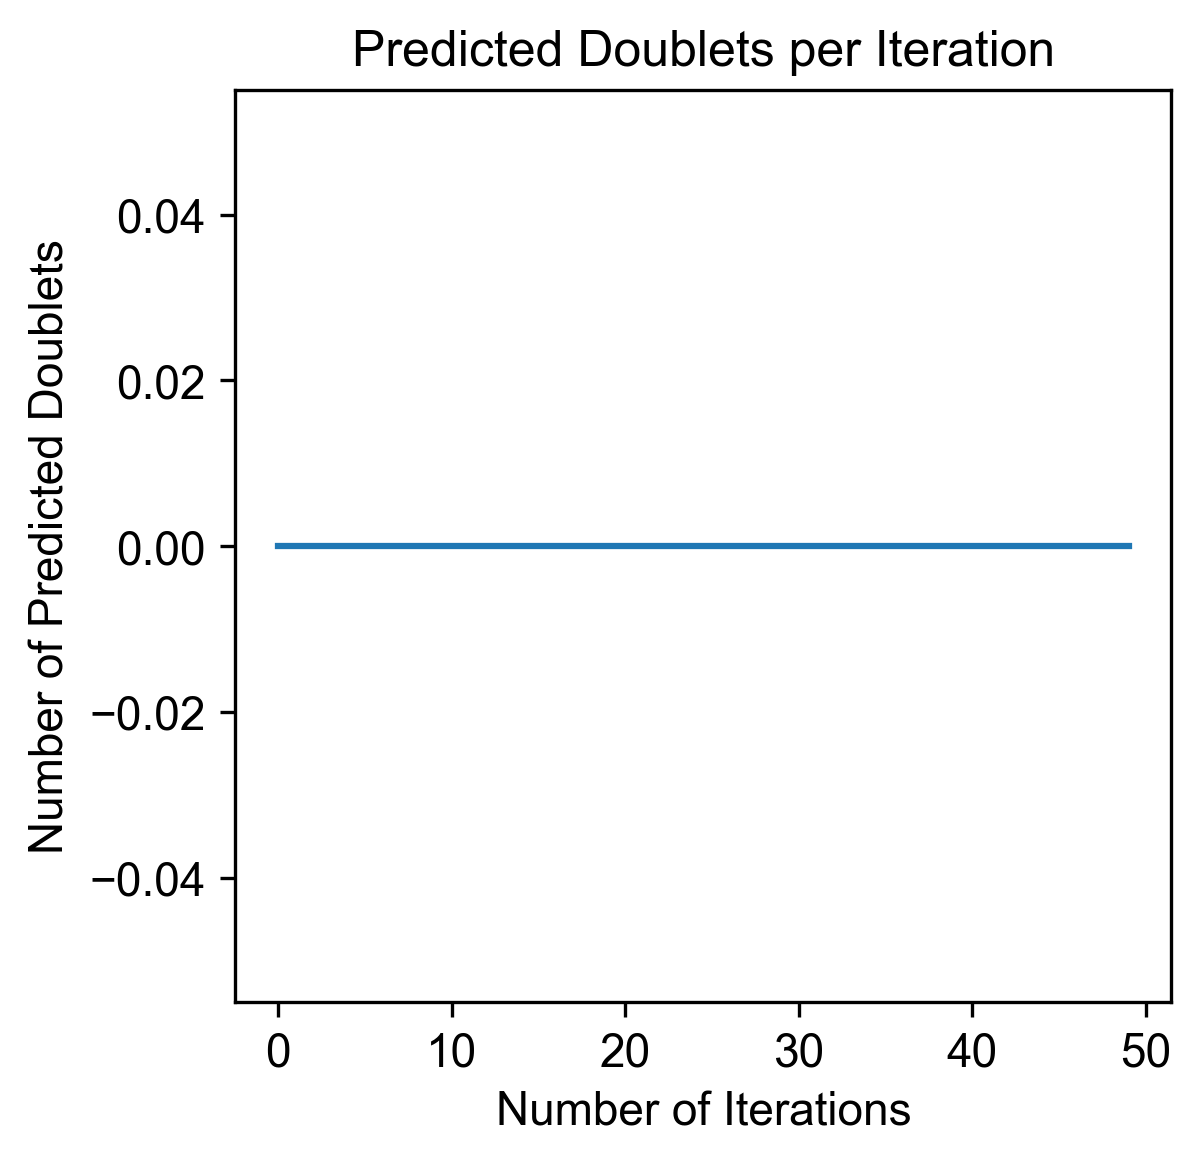

In [45]:
f = doubletdetection.plot.convergence(clf, show=True, p_thresh=1e-16, voter_thresh=0.5)

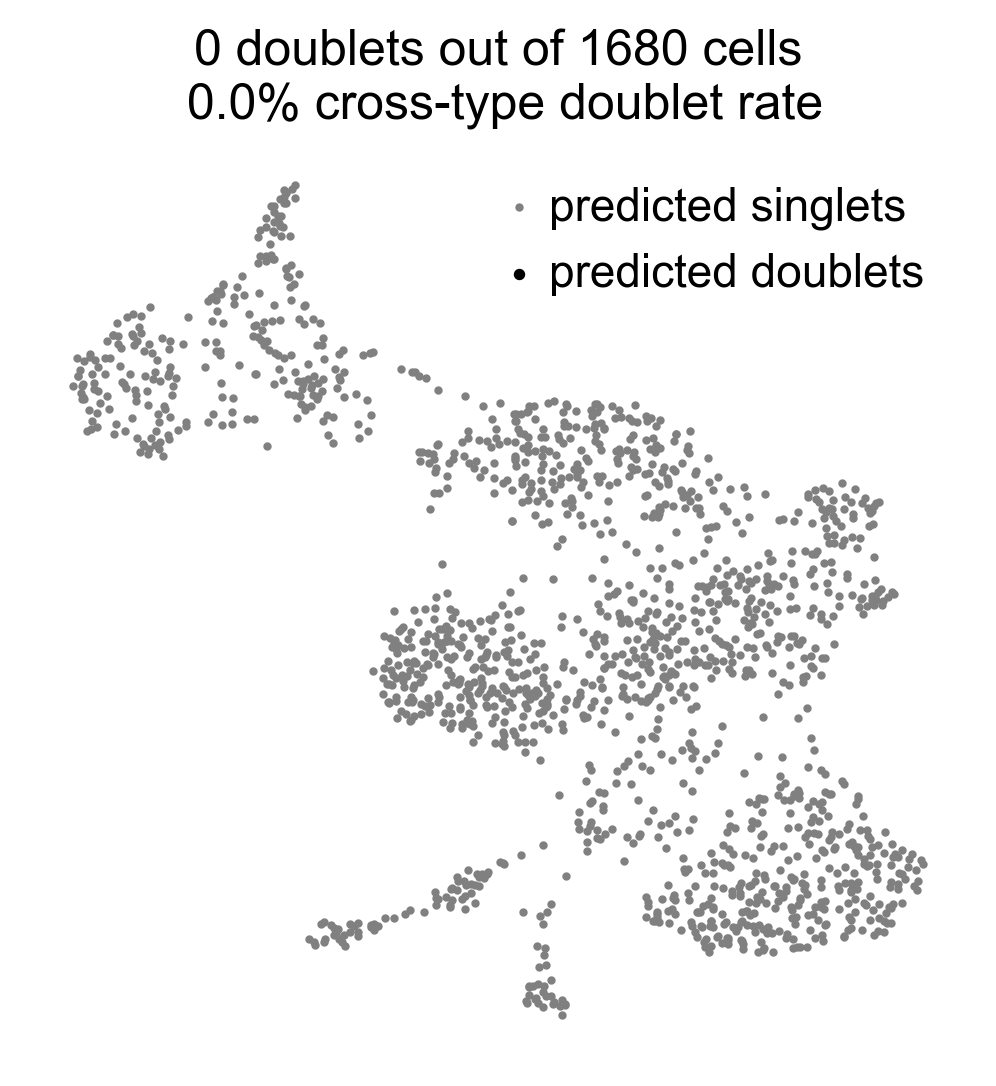

In [46]:
f2, umap_coords = doubletdetection.plot.umap_plot(adata3.X, doublets, random_state=1, show=True)

In [47]:
adata3.obs['doublet'] = list(map(str, map(int, doublets)))

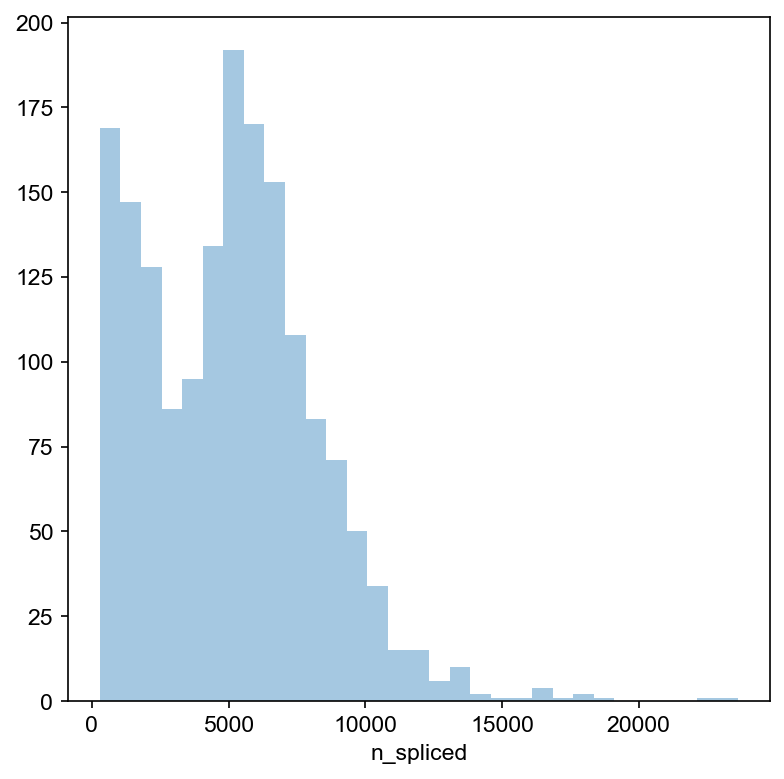

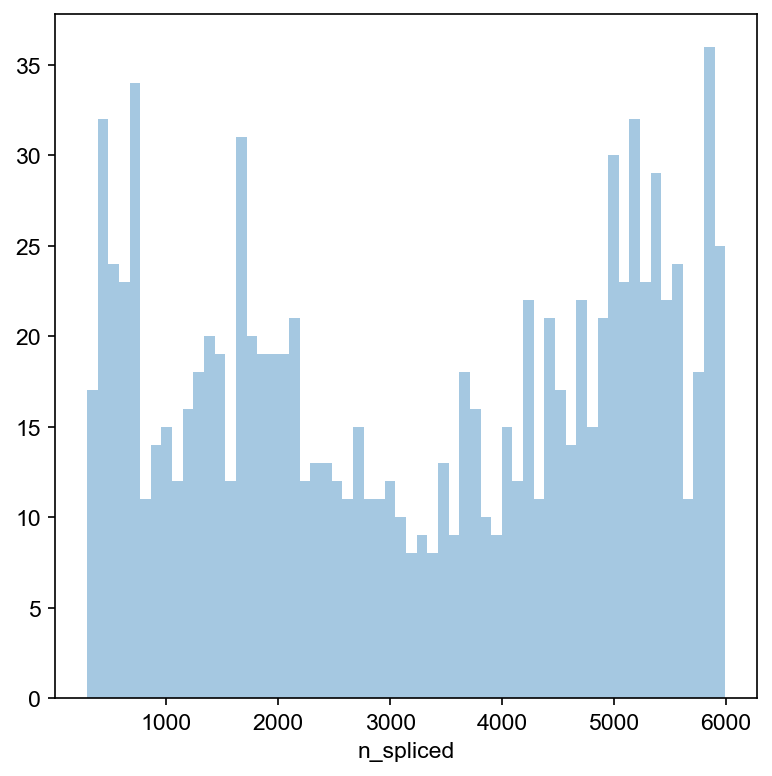

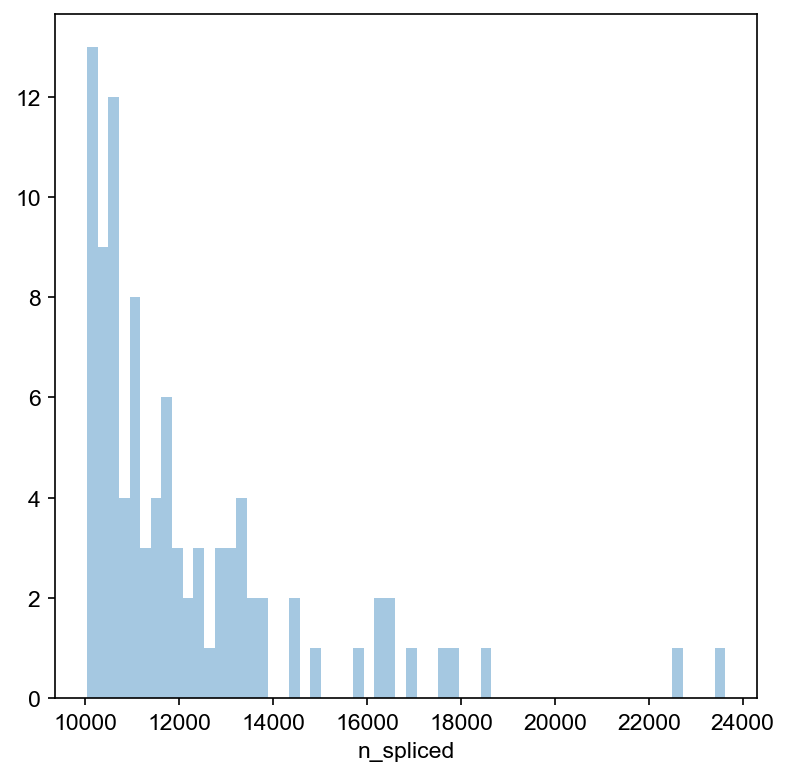

In [48]:
#Thresholding decision: spliced counts
ax=sb.distplot(adata3.obs['n_spliced'], kde=False)
plt.show()

ax=sb.distplot(adata3.obs['n_spliced'][adata3.obs['n_counts']<6000], kde=False, bins=60)
plt.show()

ax=sb.distplot(adata3.obs['n_spliced'][adata3.obs['n_counts']>10000], kde=False, bins=60)
plt.show()

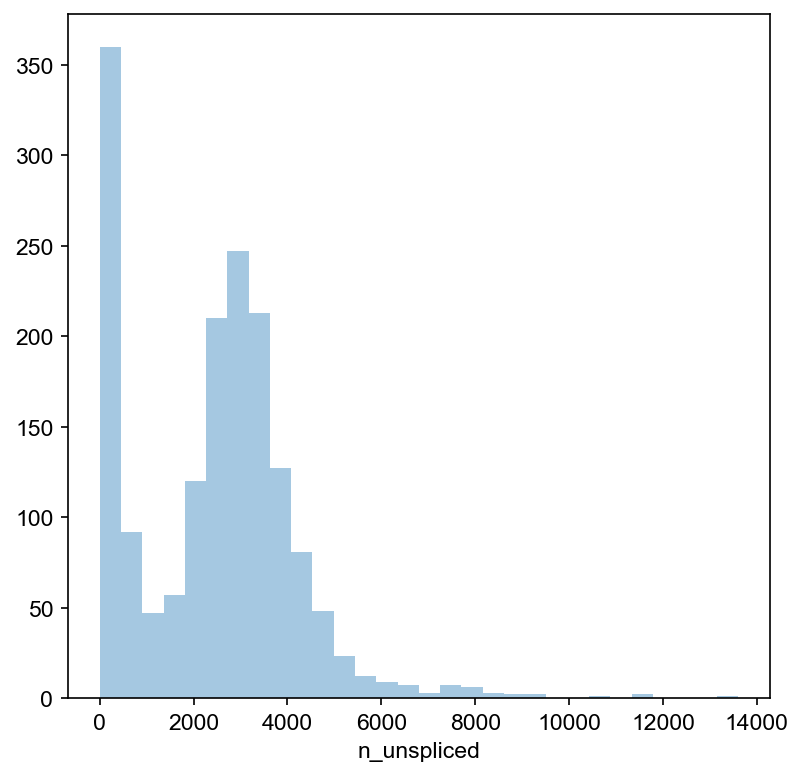

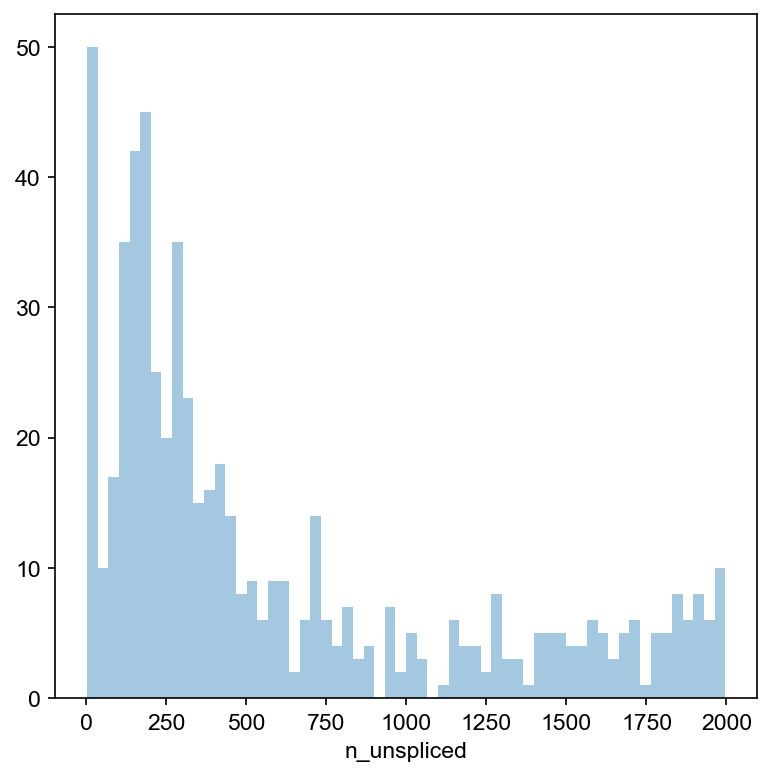

In [49]:
#Thresholding decision: unspliced counts
ax=sb.distplot(adata3.obs['n_unspliced'], kde=False)
plt.show()

ax=sb.distplot(adata3.obs['n_unspliced'][adata3.obs['n_unspliced']<2000], kde=False, bins=60)
plt.show()

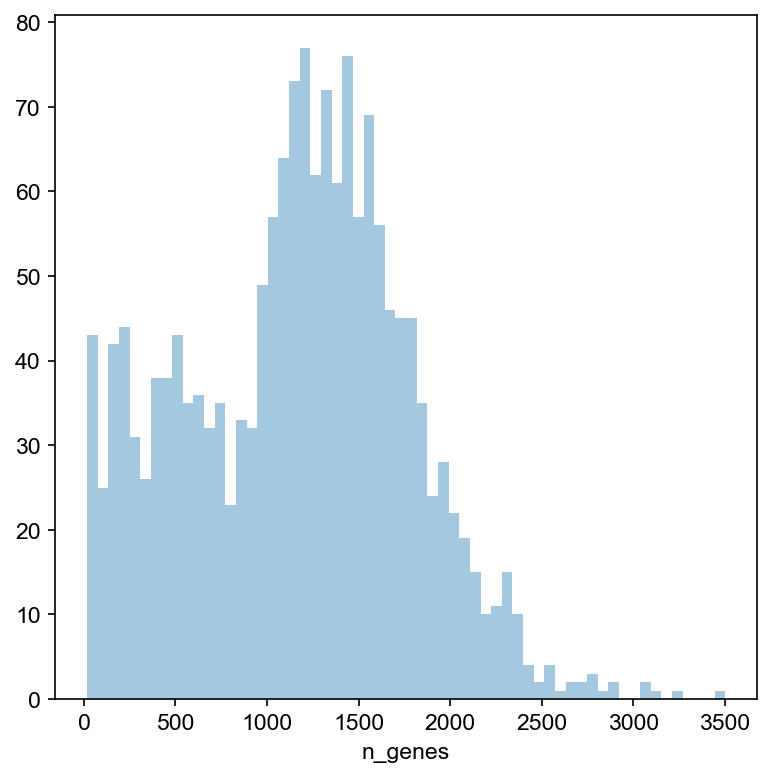

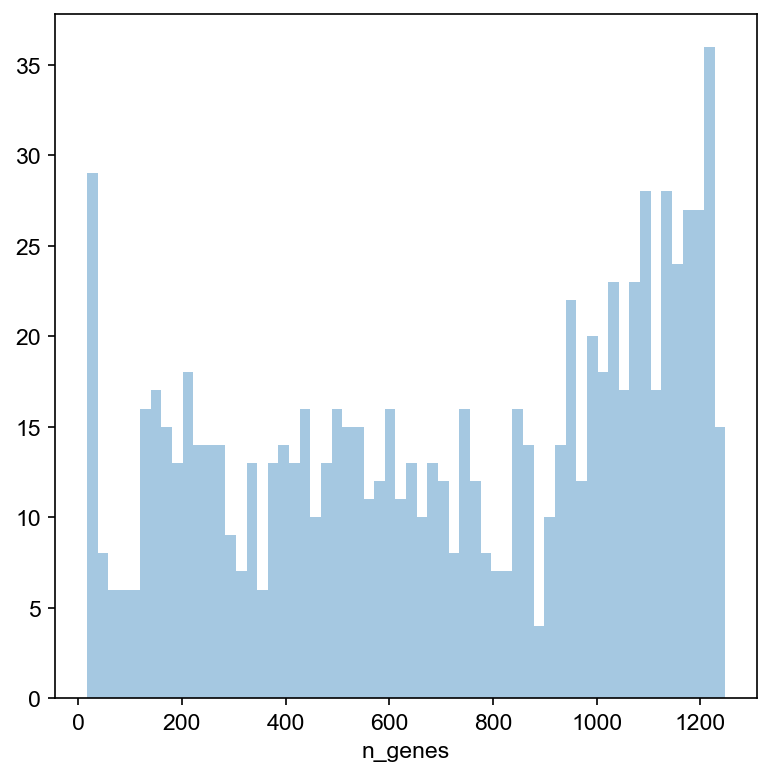

In [50]:
#Thresholding decision: genes
ax=sb.distplot(adata3.obs['n_genes'], kde=False, bins=60)
plt.show()
ax=sb.distplot(adata3.obs['n_genes'][adata3.obs['n_genes']<1250], kde=False, bins=60)
plt.show()

In [51]:
print("Cells before filtering: ", len(adata3.obs_names), "\n")

sc.pp.filter_cells(adata3, min_counts=3100)
sc.pp.filter_cells(adata3, max_counts=14000)
adata3 = adata3[adata3.obs['n_unspliced']>900]
sc.pp.filter_cells(adata3, min_genes=900)

print("Cells after filtering: ", len(adata3.obs_names))

Trying to set attribute `.obs` of view, copying.


Cells before filtering:  1680 

Cells after filtering:  1053


... storing 'doublet' as categorical


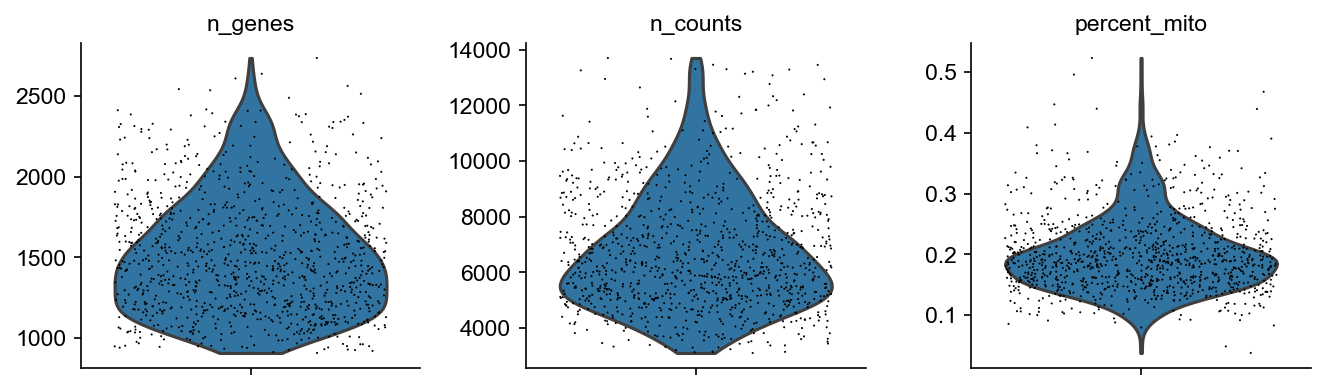

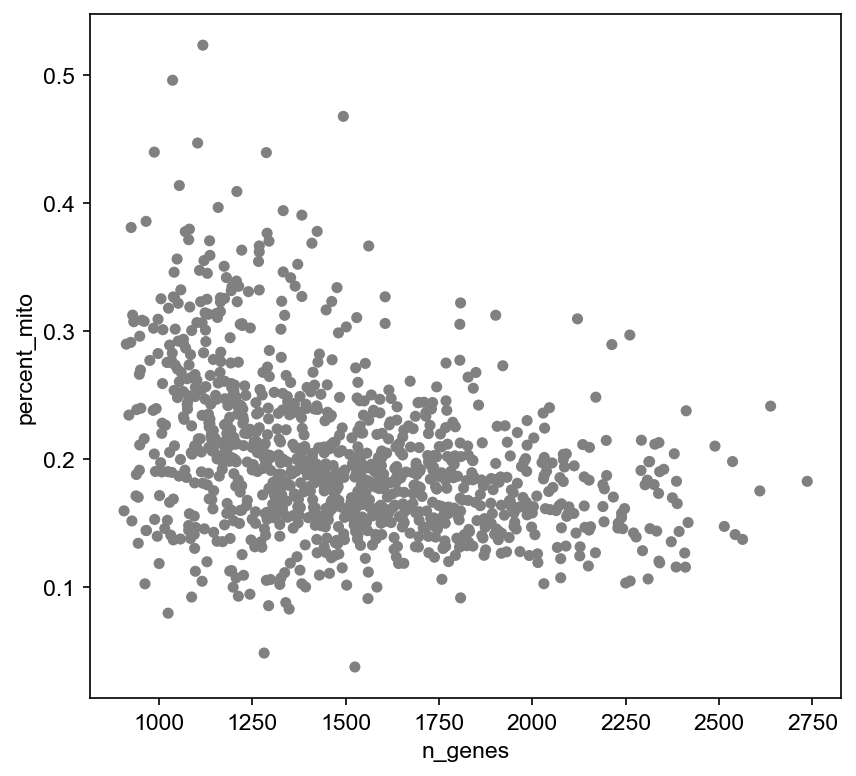

In [52]:
sc.pl.violin(adata3, ['n_genes', 'n_counts', 'percent_mito'],
             jitter=0.4, multi_panel=True)
sc.pl.scatter(adata3, 'n_genes', 'percent_mito')

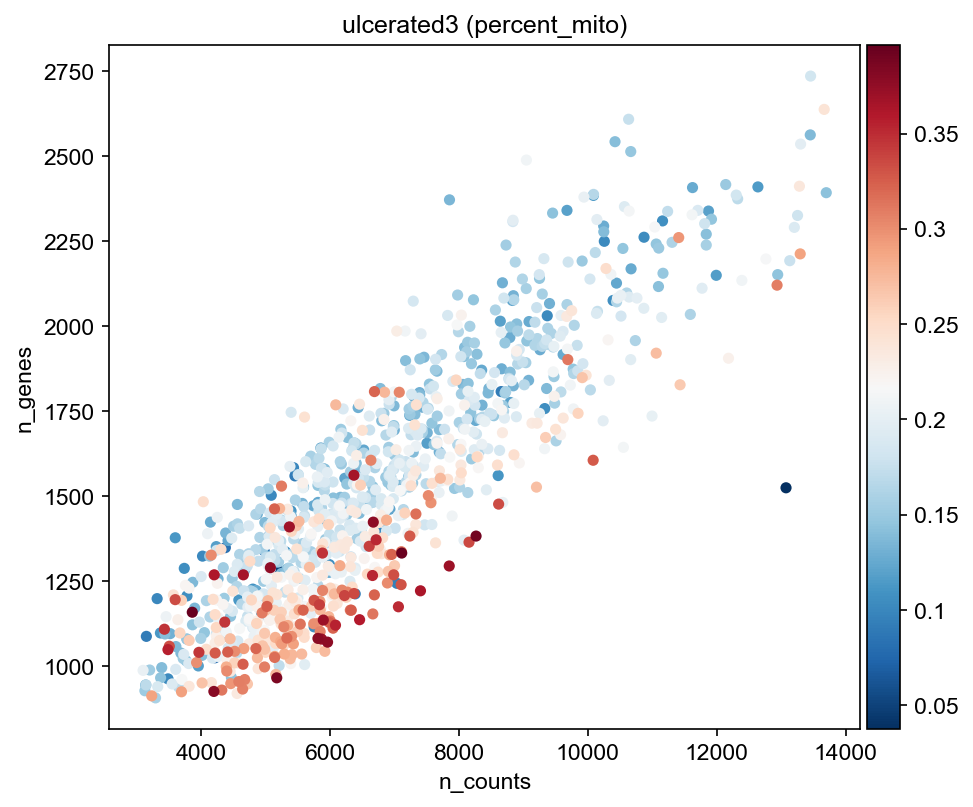

View of AnnData object with n_obs × n_vars = 1045 × 33538
    obs: 'n_counts', 'log_counts', 'n_spliced', 'n_unspliced', 'n_genes', 'percent_mito', 'percent_ribo', 'doublet_score', 'doublet'
    layers: 'matrix', 'spliced', 'unspliced'


In [53]:
adata3 = adata3[adata3.obs['percent_mito'] < 0.4, :]
sc.pl.scatter(adata3, 'n_counts', 'n_genes', color='percent_mito', title='ulcerated3 (percent_mito)')
print(adata3)

Trying to set attribute `.uns` of view, copying.


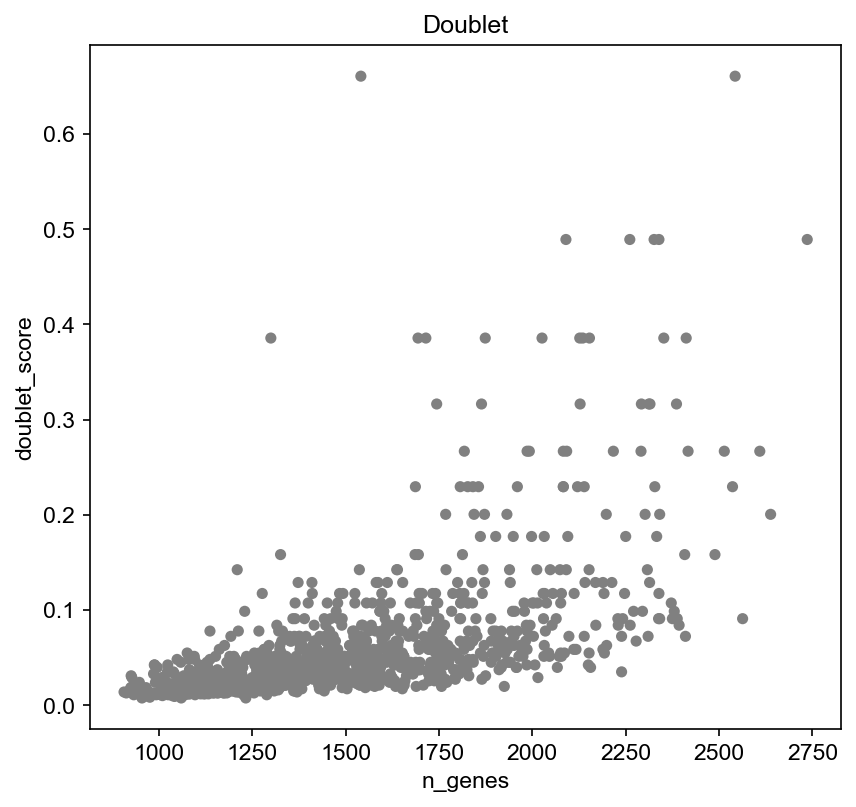

In [54]:
sc.pl.scatter(adata3, 'n_genes', 'doublet_score', color='doublet', palette=['gray', 'orange'], legend_loc='none', title='Doublet')
adata3 = adata3[adata3.obs['doublet'] != '1']
adata3 = adata3[adata3.obs['doublet_score'] < 0.3]

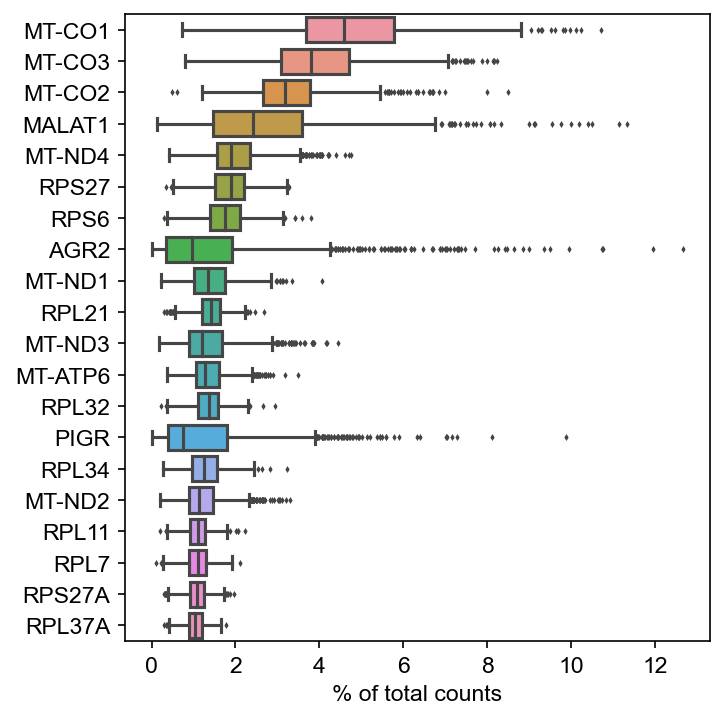

AnnData object with n_obs × n_vars = 1021 × 33538
    obs: 'n_counts', 'log_counts', 'n_spliced', 'n_unspliced', 'n_genes', 'percent_mito', 'percent_ribo', 'doublet_score', 'doublet'
    uns: 'doublet_colors'
    layers: 'matrix', 'spliced', 'unspliced'


In [55]:
sc.pl.highest_expr_genes(adata3, n_top=20)
print(adata3)

##### 2.4 ulcerated4 QC

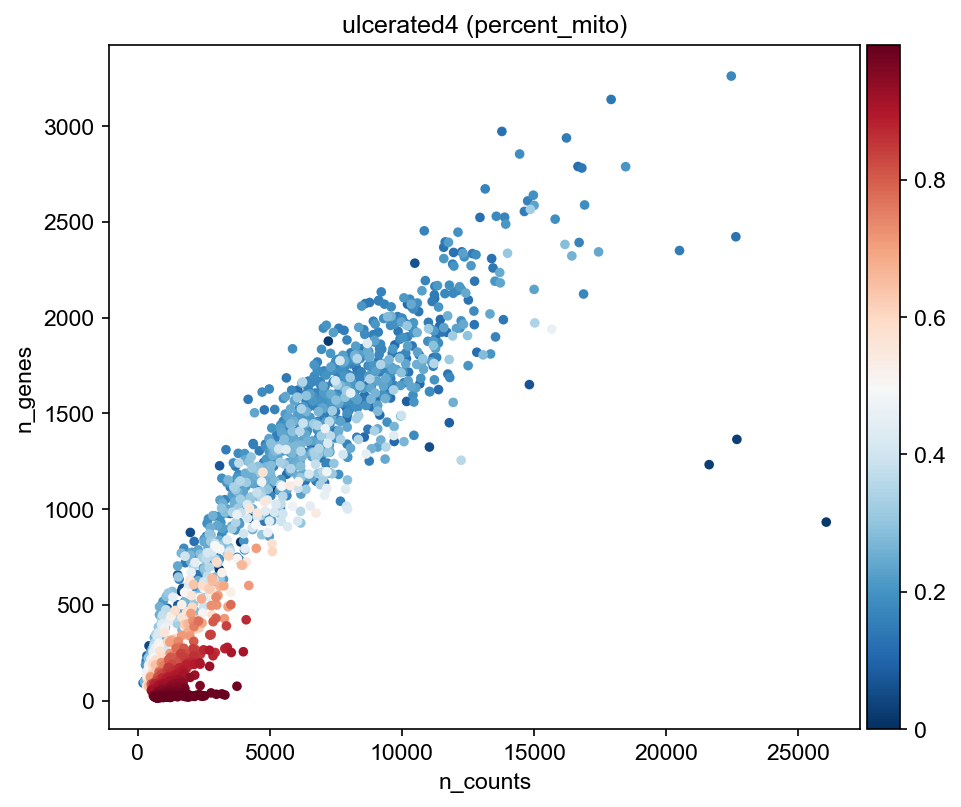

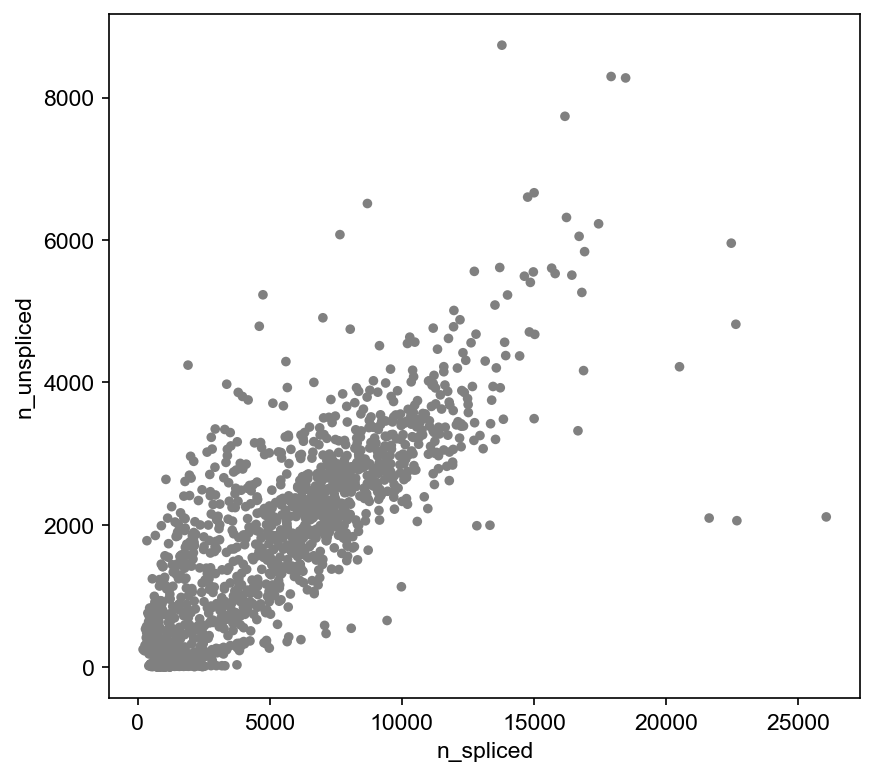

In [56]:
# Calculate QC covariates
adata4.obs['n_counts'] = adata4.X.sum(1)
adata4.obs['log_counts'] = np.log(adata4.obs['n_counts'])
adata4.obs['n_spliced'] = adata4.layers['spliced'].sum(1)
adata4.obs['n_unspliced'] = adata4.layers['unspliced'].sum(1)
adata4.obs['n_genes'] = (adata4.X > 0).sum(1)
# Compute for each cell the fraction of counts in mito genes vs. all genes
mito_genes = adata4.var_names.str.startswith('MT-')
adata4.obs['percent_mito'] = np.sum(
    adata4[:, mito_genes].X, axis=1) / np.sum(adata4.X, axis=1)
# Compute for each cell the fraction of counts in ribosomal genes vs. all genes
ribo_genes = adata4.var_names.str.startswith('RP')
adata4.obs['percent_ribo'] = np.sum(
    adata4[:, ribo_genes].X, axis=1) / np.sum(adata4.X, axis=1)

sc.pl.scatter(adata4, 'n_counts', 'n_genes', color='percent_mito', title='ulcerated4 (percent_mito)')
sc.pl.scatter(adata4, 'n_spliced', 'n_unspliced')

In [57]:
# Doublet analysis
scrub = scr.Scrublet(adata4.X, expected_doublet_rate=0.06)
doublet_scores, predicted_doublets = scrub.scrub_doublets(min_counts=2, 
                                                          min_cells=3, 
                                                          min_gene_variability_pctl=85, 
                                                          n_prin_comps=30,
                                                          mean_center=False, 
                                                          normalize_variance=False,
                                                          log_transform=True)

Preprocessing...
Simulating doublets...
Embedding transcriptomes using Truncated SVD...
Calculating doublet scores...
Automatically set threshold at doublet score = 0.43
Detected doublet rate = 0.6%
Estimated detectable doublet fraction = 6.5%
Overall doublet rate:
	Expected   = 6.0%
	Estimated  = 8.7%
Elapsed time: 0.6 seconds


(<Figure size 600x225 with 2 Axes>,
 array([<matplotlib.axes._subplots.AxesSubplot object at 0x7fb5088fd208>,
       dtype=object))

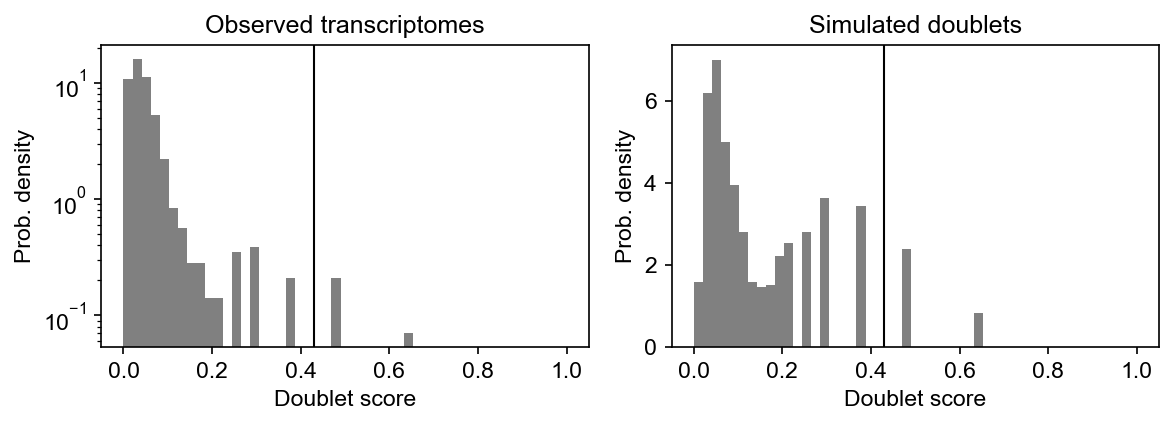

In [58]:
scrub.plot_histogram()

(<Figure size 600x300 with 3 Axes>,
 array([<matplotlib.axes._subplots.AxesSubplot object at 0x7fb57aee9eb8>,
       dtype=object))

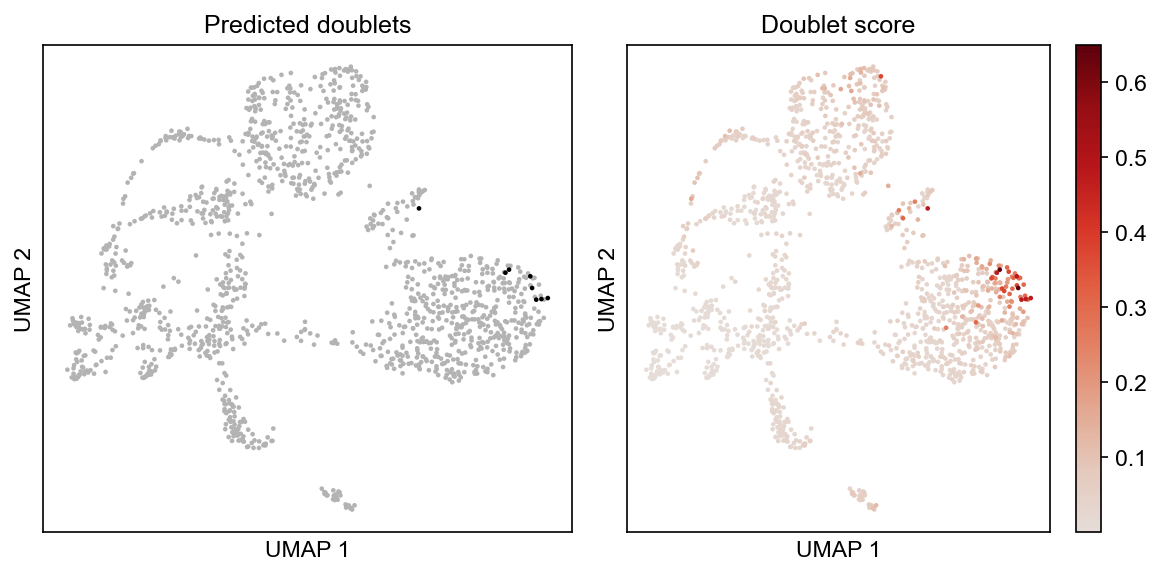

In [59]:
scrub.set_embedding('UMAP', scr.get_umap(scrub.manifold_obs_, 10, min_dist=0.3))
scrub.plot_embedding('UMAP', order_points=True)

In [60]:
adata4.obs['doublet_score'] = scrub.doublet_scores_obs_

Another tool to annotate doublets is Doublet Detection. More sophisticated, we use it to actually call doublets.

In [61]:
clf = doubletdetection.BoostClassifier(n_iters=50, use_phenograph=False, standard_scaling=True)
doublets = clf.fit(adata4.X).predict(p_thresh=1e-16, voter_thresh=0.5)

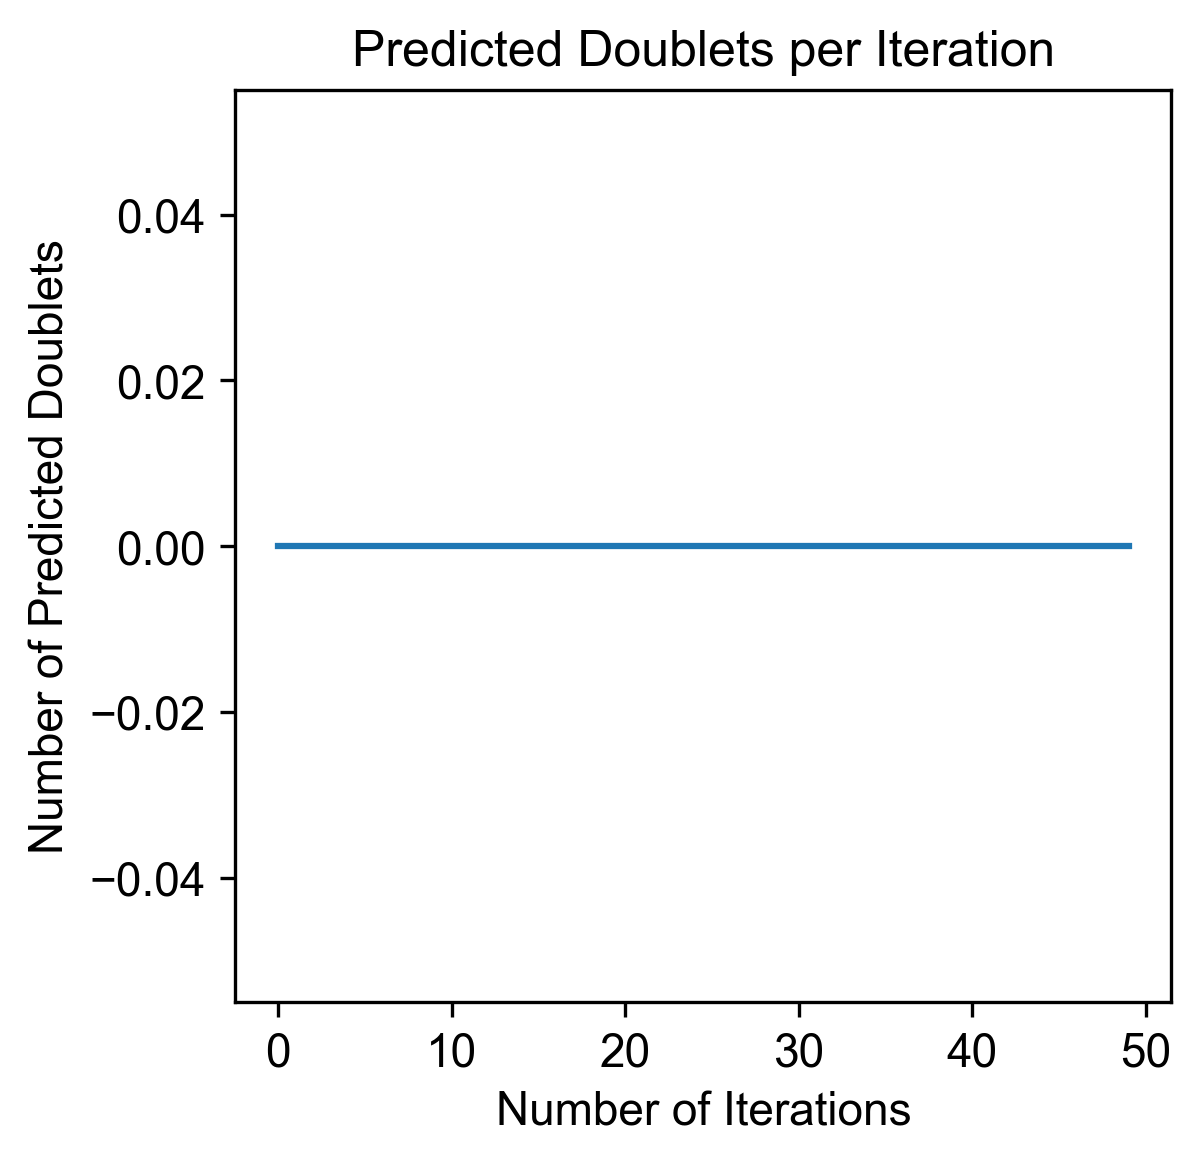

In [62]:
f = doubletdetection.plot.convergence(clf, show=True, p_thresh=1e-16, voter_thresh=0.5)

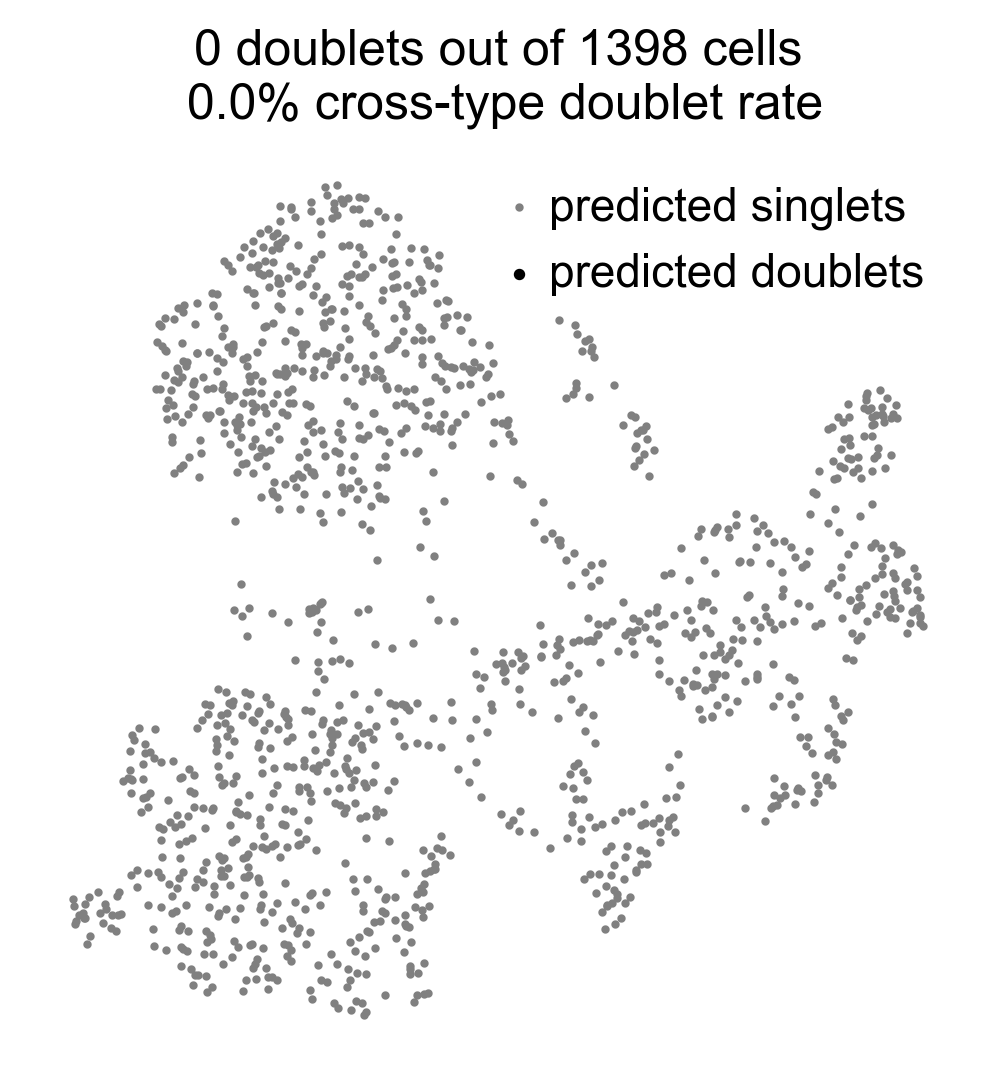

In [63]:
f2, umap_coords = doubletdetection.plot.umap_plot(adata4.X, doublets, random_state=1, show=True)

In [64]:
adata4.obs['doublet'] = list(map(str, map(int, doublets)))

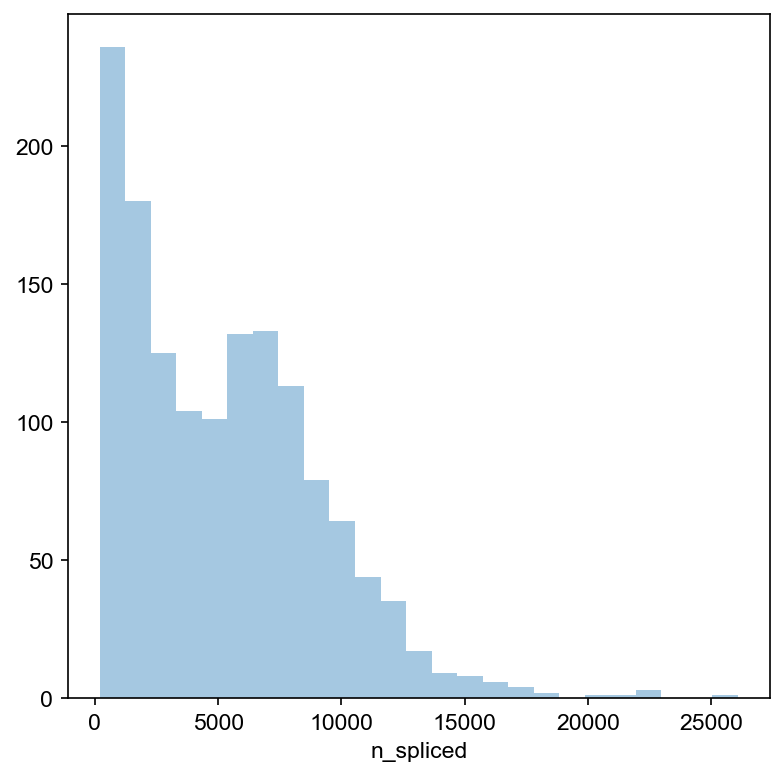

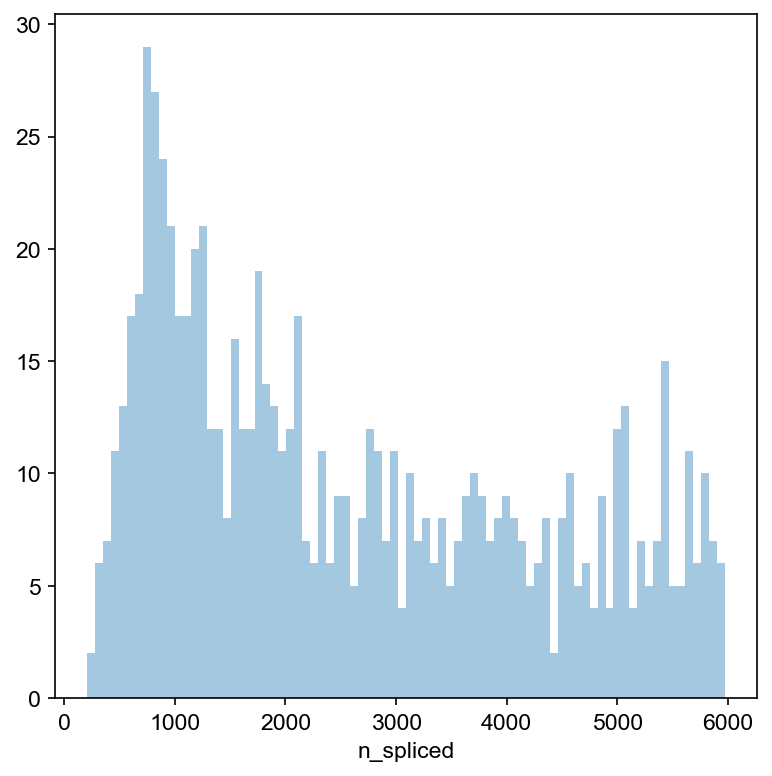

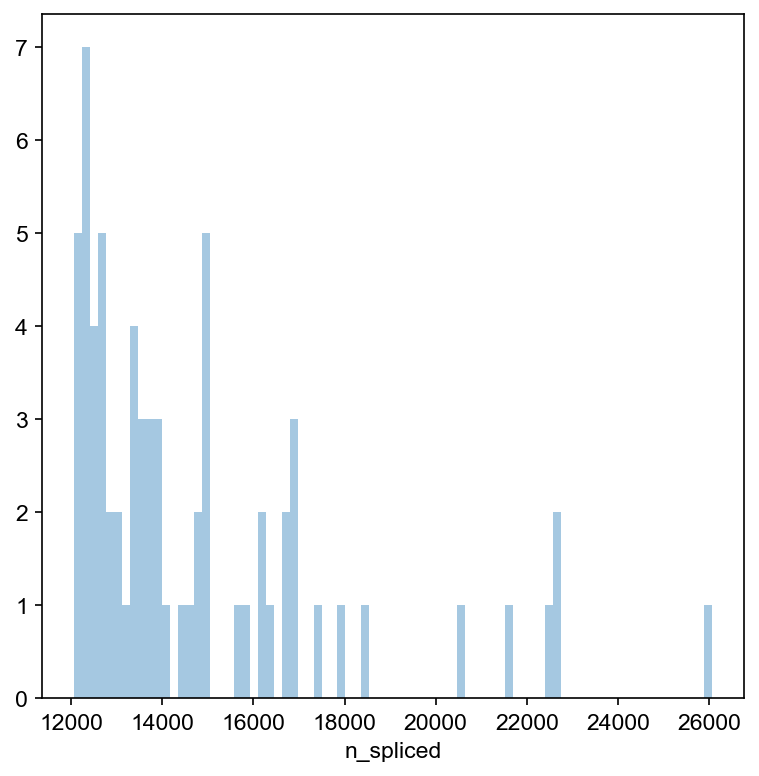

In [65]:
#Thresholding decision: spliced counts
ax=sb.distplot(adata4.obs['n_spliced'], kde=False)
plt.show()

ax=sb.distplot(adata4.obs['n_spliced'][adata4.obs['n_counts']<6000], kde=False, bins=80)
plt.show()

ax=sb.distplot(adata4.obs['n_spliced'][adata4.obs['n_counts']>12000], kde=False, bins=80)
plt.show()

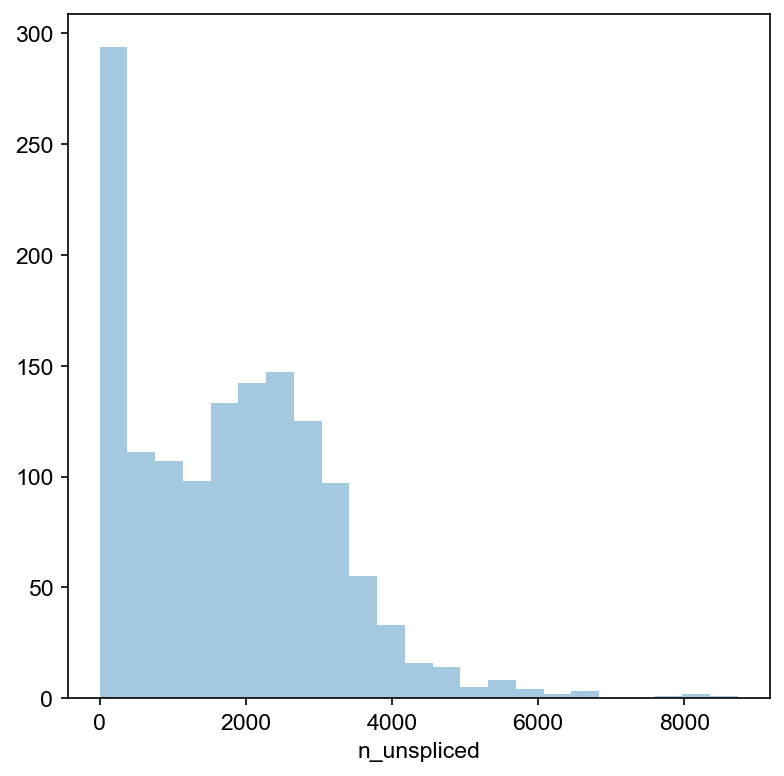

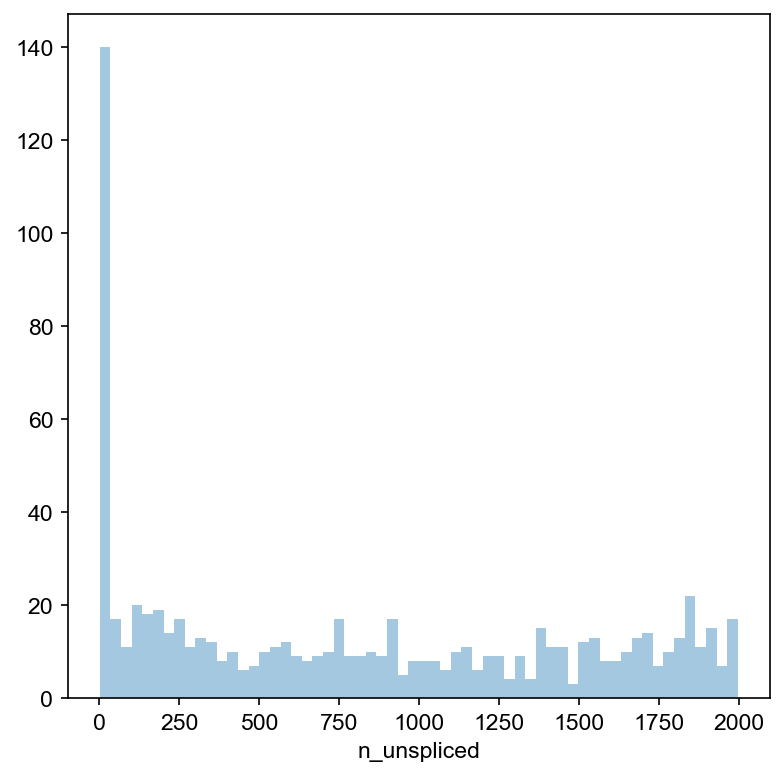

In [66]:
#Thresholding decision: unspliced counts
ax=sb.distplot(adata4.obs['n_unspliced'], kde=False)
plt.show()

ax=sb.distplot(adata4.obs['n_unspliced'][adata4.obs['n_unspliced']<2000], kde=False, bins=60)
plt.show()

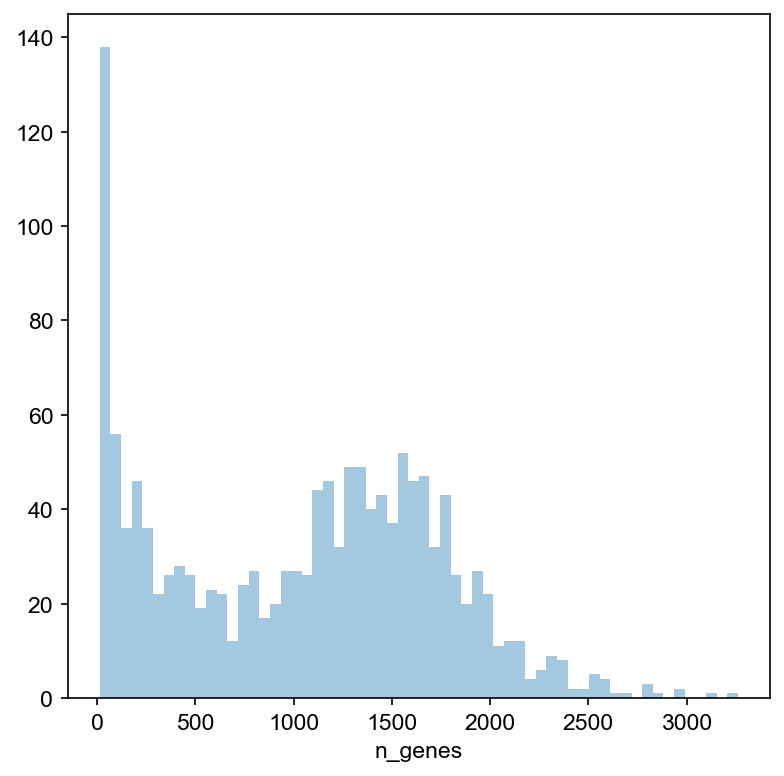

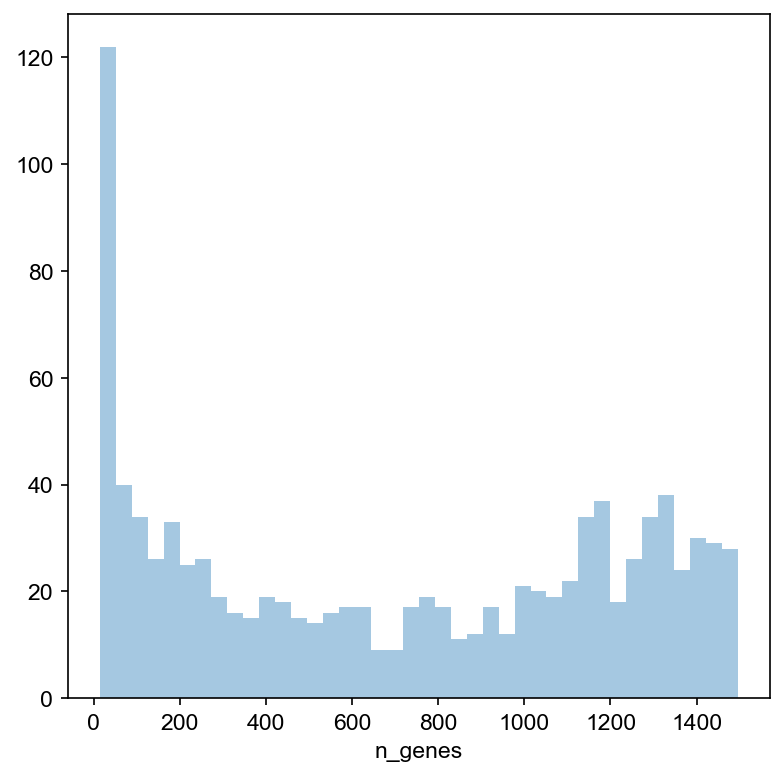

In [67]:
#Thresholding decision: genes
ax=sb.distplot(adata4.obs['n_genes'], kde=False, bins=60)
plt.show()
ax=sb.distplot(adata4.obs['n_genes'][adata4.obs['n_genes']<1500], kde=False, bins=40)
plt.show()

In [68]:
print("Cells before filtering: ", len(adata4.obs_names), "\n")

sc.pp.filter_cells(adata4, min_counts=3500)
sc.pp.filter_cells(adata4, max_counts=17000)
adata4 = adata4[adata4.obs['n_unspliced']>500]
sc.pp.filter_cells(adata4, min_genes=800)

print("Cells after filtering: ", len(adata4.obs_names))

Trying to set attribute `.obs` of view, copying.


Cells before filtering:  1398 

Cells after filtering:  802


... storing 'doublet' as categorical


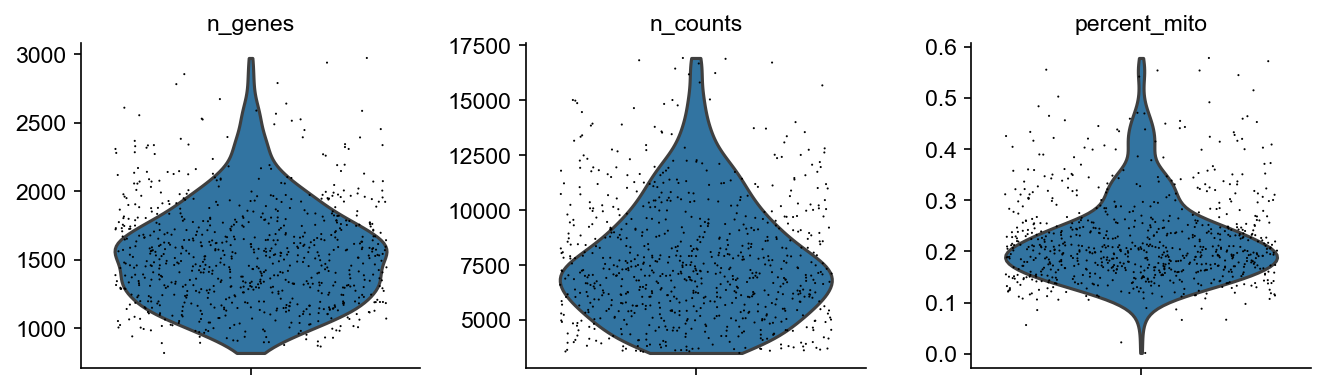

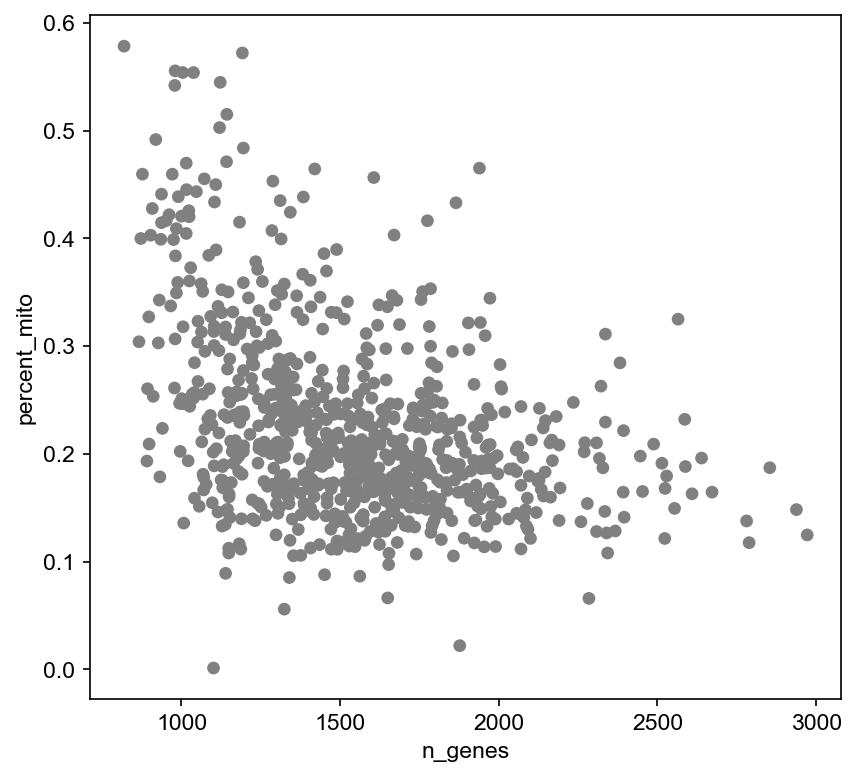

In [69]:
sc.pl.violin(adata4, ['n_genes', 'n_counts', 'percent_mito'],
             jitter=0.4, multi_panel=True)
sc.pl.scatter(adata4, 'n_genes', 'percent_mito')

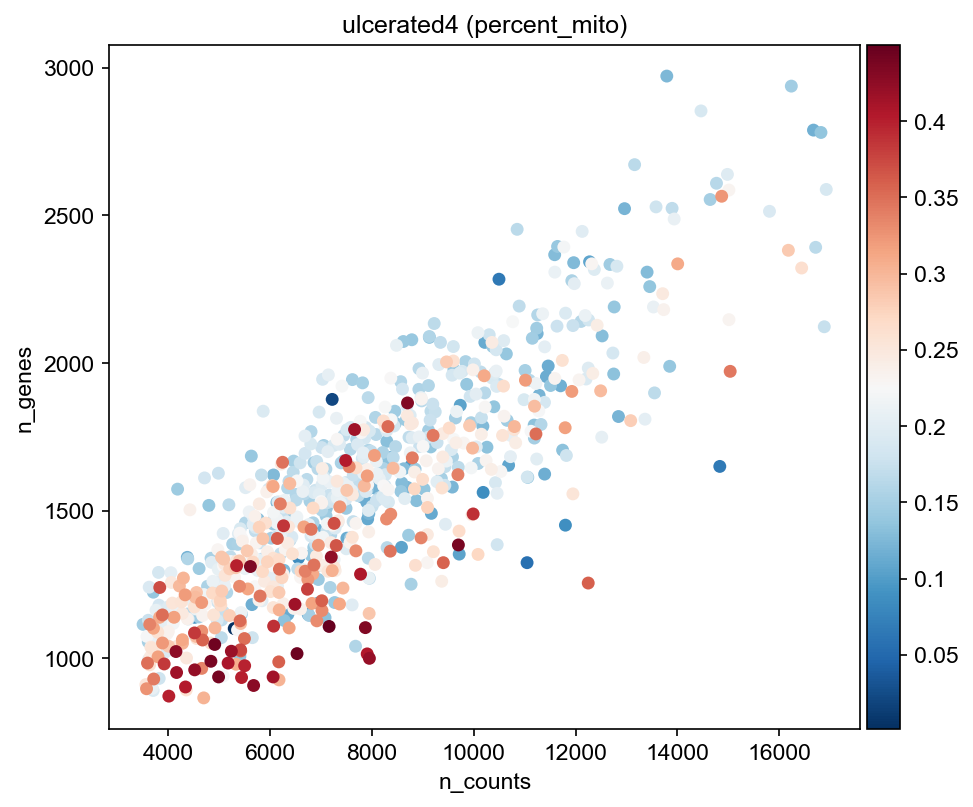

View of AnnData object with n_obs × n_vars = 782 × 33538
    obs: 'n_counts', 'log_counts', 'n_spliced', 'n_unspliced', 'n_genes', 'percent_mito', 'percent_ribo', 'doublet_score', 'doublet'
    layers: 'matrix', 'spliced', 'unspliced'


In [70]:
adata4 = adata4[adata4.obs['percent_mito'] < 0.45, :]
sc.pl.scatter(adata4, 'n_counts', 'n_genes', color='percent_mito', title='ulcerated4 (percent_mito)')
print(adata4)

Trying to set attribute `.uns` of view, copying.


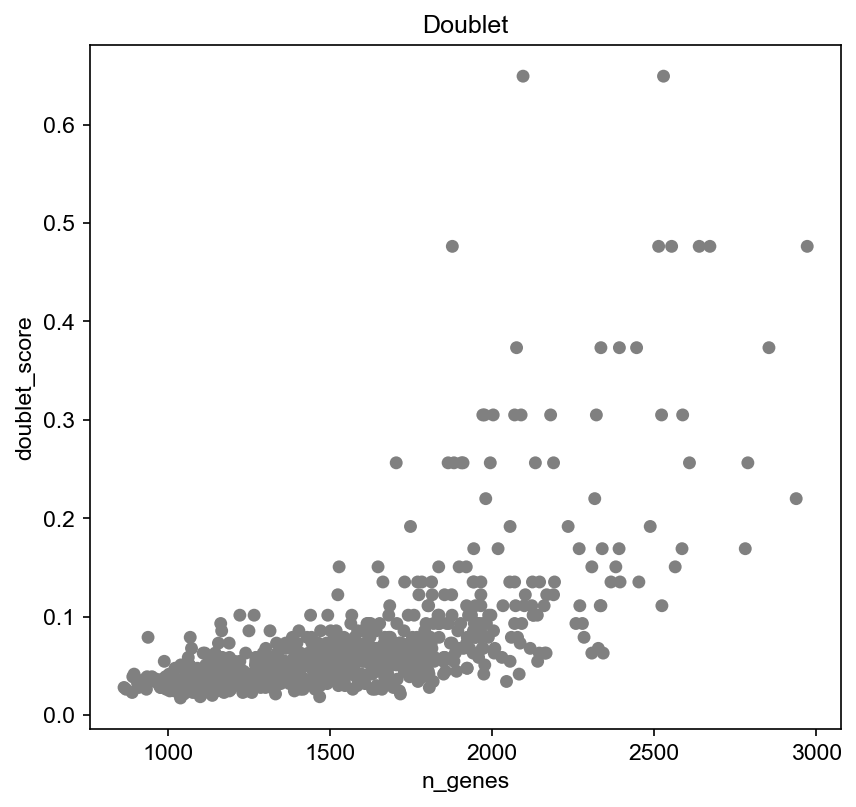

In [71]:
sc.pl.scatter(adata4, 'n_genes', 'doublet_score', color='doublet', palette=['gray', 'orange'], legend_loc='none', title='Doublet')
adata4 = adata4[adata4.obs['doublet'] != '1']
adata4 = adata4[adata4.obs['doublet_score'] < 0.3]

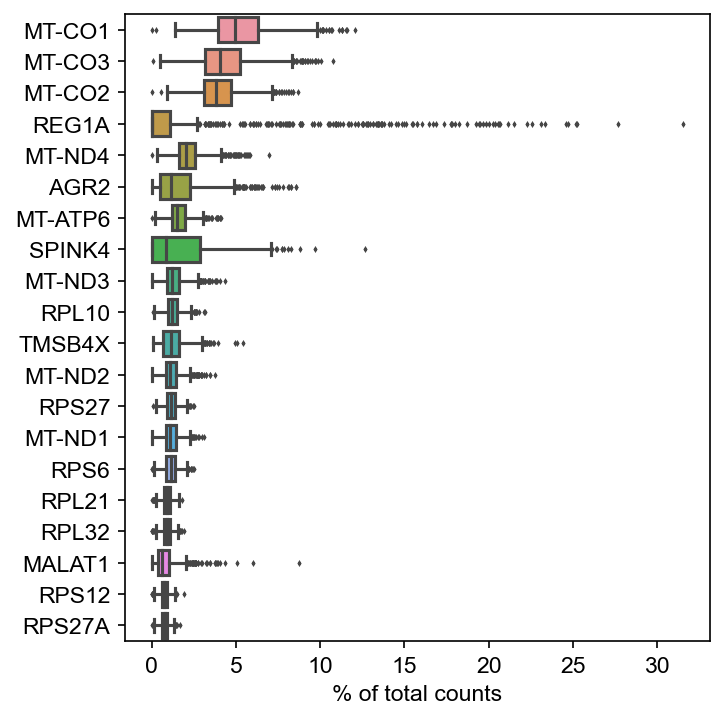

AnnData object with n_obs × n_vars = 760 × 33538
    obs: 'n_counts', 'log_counts', 'n_spliced', 'n_unspliced', 'n_genes', 'percent_mito', 'percent_ribo', 'doublet_score', 'doublet'
    uns: 'doublet_colors'
    layers: 'matrix', 'spliced', 'unspliced'


In [72]:
sc.pl.highest_expr_genes(adata4, n_top=20)
print(adata4)

#### 3. Merge samples

In [73]:
adata = adata1.concatenate(adata2, adata3, adata4,
                           batch_key='Sample', 
                           batch_categories=['ulcerated1', 'ulcerated2', 'ulcerated3', 'ulcerated4'])
# Apply workaround necessary due to bugs in code
adata.layers['spliced'] = adata.layers['spliced'].astype(float)
adata.layers['unspliced'] = adata.layers['unspliced'].astype(float)

# Filter out genes expressed in less than 5 cells
scv.pp.filter_genes(adata, min_cells=5)
# Filter out genes with less than 20 counts across all cells
scv.pp.filter_genes(adata, min_counts=20)

adata

Filtered out 18002 genes that are detected in less than 5 cells (spliced).
Filtered out 2642 genes that are detected 20 counts (spliced).


AnnData object with n_obs × n_vars = 4351 × 12894
    obs: 'n_counts', 'log_counts', 'n_spliced', 'n_unspliced', 'n_genes', 'percent_mito', 'percent_ribo', 'doublet_score', 'doublet', 'Sample', 'initial_size_spliced', 'initial_size_unspliced', 'initial_size'
    layers: 'matrix', 'spliced', 'unspliced'

#### 4.Save data for the next step 

In [74]:
adata.write("ulcerated_qc.h5ad")